### EDA

- Below is a concise exploratory analysis highlighting the most relevant characteristics of the dataset.  
- The dataset contains 41 features: 22 numerical and 20 categorical.  

- The target is highly imbalanced, with only 1.4% positive cases.  
- 15 features contain missing values.  
- While some feature meanings can be partially inferred, they are not fully defined.  

- Several features exhibit strong correlations, primarily due to being derived from similar underlying drivers; however, no perfect multicollinearity is observed.  

- For features with missing values, the default rate often differs significantly between observations with and without missing data, suggesting that missingness itself may carry predictive signal (though this is not formally validated).  

- Features were analyzed by comparing their distributions and default rates against the baseline default rate. Numerical variables were first discretized into bins for this purpose.  

- Given the large number of features, not all were examined in detail. While many show meaningful predictive potential, the following appear to have particularly strong explanatory power:  
  - account_status  
  - account_worst_status  
  - age  
  - merchant_group  
  - num_active_div_by_paid_inv  
  - num_unpaid_bills  
  - status_last_archived  



In [ ]:
import pandas as pd
import numpy as np
import warnings
import random
import sys
import os
import matplotlib.pyplot as plt
sys.path.append(os.path.abspath(".."))
from plot_utils import plot_bars_rel, plot_binary_distribution
from sklearn.model_selection import train_test_split
from statsmodels.stats.proportion import proportions_ztest
warnings.filterwarnings('ignore')


pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 1000)
pd.options.display.float_format = '{:.5f}'.format

df = pd.read_csv("../data/dataset.csv", sep = ";")
df['has_paid'] = df['has_paid'].astype(int)

df_nna = df[df['default'].notna()]  # observations for which we have default values (Training + Validation set)
#df_na = df[df['default'].isna()]    # observations for which we dont have default values (Unlabeled data)

X = df_nna.drop(columns=["default"])
y = df_nna["default"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, random_state=42
)

df_train = pd.concat([X_train, y_train], axis=1)

#### Properties of individual features

In [50]:
## Testing if the observations with NAs have different Default Rates than the observations without NAs.

nna_perc = list(df_train.apply(lambda x: np.mean(df_train['default'][x.notna()])))
nna_def = list(df_train.apply(lambda x: int(np.sum(df_train['default'][x.notna()]))))
nna_all = list(df_train.apply(lambda x: len(df_train['default'][x.notna()])))

na_perc  = list(df_train.apply(lambda x: np.mean(df_train['default'][x.isna()])))
na_def  = list(df_train.apply(lambda x: int(np.sum(df_train['default'][x.isna()]))))
na_all  = list(df_train.apply(lambda x: len(df_train['default'][x.isna()])))
cols = list(df_train.columns)

na_nna_compare = pd.DataFrame({'VarName': cols,
                               '% Default Not NAs': nna_perc,
                               'Count Default Not NAs': nna_def,
                               'Count All Not NAs': nna_all,
                               '% Default NAs': na_perc,
                               'Count Default NAs': na_def,
                               'Count All NAs': na_all})

                       

na_nna_compare.dropna(inplace=True)

print('Features with NAs')
display(na_nna_compare)     


def p_value(a,b,c,d):
    count = [a, b]      
    nobs = [c, d]          
    stat, pval = proportions_ztest(count, nobs)
    #pval=str(a/c) +''+str(b/d)
    return pval

na_nna_compare['proportions test_p value'] = na_nna_compare.apply(lambda x: p_value(x['Count Default Not NAs'], x['Count Default NAs'], x['Count All Not NAs'], x['Count All NAs'] ), axis=1)
na_nna_compare


def num_cat(df):
    df_num_cat = pd.DataFrame(columns=['Columns', 'Unique Val','Unique Val Count'])
    for col in df.columns:
        row = pd.DataFrame({'Columns': [col], 'Unique Val': [df_train[col].unique(),], 'Unique Val Count': [len(df_train[col].unique())]})
        df_num_cat = pd.concat([df_num_cat,row])
        
    df_num_cat['Variable Type'] = np.where((df_num_cat['Unique Val Count'] <15) , 'Categorical', 'Numerical')
    df_num_cat['Variable Type'] = np.where(df_num_cat['Columns'].isin(['merchant_category','merchant_group', 'name_in_email']), 'Categorical', df_num_cat['Variable Type'])
    df_num_cat['Has NA'] = np.where(df_num_cat['Columns'].isin(list(na_nna_compare['VarName'])), 'Yes', 'No')

    df_num_cat['Variable Type'] = np.where(df_num_cat['Columns'].isin(['uuid','default']), '/', df_num_cat['Variable Type'])
    return df_num_cat

df_num_cat = num_cat(df_nna) 

print('All Features')
display(df_num_cat) 


print('Categorical features and numerical features with NaNs - good candidates for WoE encoding')
display(df_num_cat['Columns'][(df_num_cat['Columns'].isin(list(na_nna_compare['VarName']))) | (df_num_cat['Variable Type'] == 'Categorical')])

Features with NAs


,VarName,% Default Not NAs,Count Default Not NAs,Count All Not NAs,% Default NAs,Count Default NAs,Count All NAs
2,account_days_in_dc_12_24m,0.01505,895,59483,0.00888,71,7999
3,account_days_in_rem_12_24m,0.01505,895,59483,0.00888,71,7999
4,account_days_in_term_12_24m,0.01505,895,59483,0.00888,71,7999
5,account_incoming_debt_vs_paid_0_24m,0.01955,539,27564,0.01070,427,39918
6,account_status,0.02032,627,30862,0.00926,339,36620
7,account_worst_status_0_3m,0.02032,627,30862,0.00926,339,36620
8,account_worst_status_12_24m,0.01810,407,22489,0.01242,559,44993
9,account_worst_status_3_6m,0.01886,540,28628,0.01096,426,38854
10,account_worst_status_6_12m,0.01823,489,26827,0.01173,477,40655
12,avg_payment_span_0_12m,0.00999,514,51476,0.02824,452,16006


All Features


,Columns,Unique Val,Unique Val Count,Variable Type,Has NA
0,uuid,"[39097, 41297, 36085, 20518, 26174, 34079, 133...",67482,/,No
0,default,"[0.0, 1.0]",2,/,No
0,account_amount_added_12_24m,"[0, 19231, 253866, 9956, 47454, 30839, 32303, ...",16957,Numerical,No
0,account_days_in_dc_12_24m,"[0.0, nan, 99.0, 14.0, 42.0, 67.0, 9.0, 52.0, ...",108,Numerical,Yes
0,account_days_in_rem_12_24m,"[0.0, 76.0, nan, 119.0, 44.0, 35.0, 33.0, 20.0...",261,Numerical,Yes
0,account_days_in_term_12_24m,"[0.0, nan, 2.0, 34.0, 46.0, 14.0, 1.0, 7.0, 22...",59,Numerical,Yes
0,account_incoming_debt_vs_paid_0_24m,"[nan, 0.151693667157585, 0.0096930533117932, 1...",16634,Numerical,Yes
0,account_status,"[nan, 1.0, 2.0, 3.0]",4,Categorical,Yes
0,account_worst_status_0_3m,"[nan, 1.0, 2.0, 3.0, 4.0]",5,Categorical,Yes
0,account_worst_status_12_24m,"[nan, 1.0, 2.0, 3.0, 4.0]",5,Categorical,Yes


Categorical features and numerical features with NaNs - good candidates for WoE encoding


0              account_days_in_dc_12_24m
0             account_days_in_rem_12_24m
0            account_days_in_term_12_24m
0    account_incoming_debt_vs_paid_0_24m
0                         account_status
0              account_worst_status_0_3m
0            account_worst_status_12_24m
0              account_worst_status_3_6m
0             account_worst_status_6_12m
0                 avg_payment_span_0_12m
0                  avg_payment_span_0_3m
0                      merchant_category
0                         merchant_group
0                               has_paid
0                          name_in_email
0       num_active_div_by_paid_inv_0_12m
0                      num_arch_dc_0_12m
0                     num_arch_dc_12_24m
0             num_arch_written_off_0_12m
0            num_arch_written_off_12_24m
0             status_last_archived_0_24m
0         status_2nd_last_archived_0_24m
0         status_3rd_last_archived_0_24m
0         status_max_archived_0_6_months
0        status_

In [65]:
print('Categorical features with NaNs')
cat_na_list = list(df_num_cat[(df_num_cat['Variable Type']=='Categorical') & (df_num_cat['Has NA']=='Yes')].Columns)
print(cat_na_list)
print(len(cat_na_list))

print('Categorical features no NaNs')
cat_no_na_list = list(df_num_cat[(df_num_cat['Variable Type']=='Categorical') & (df_num_cat['Has NA']=='No')].Columns)
print(cat_no_na_list)
print(len(cat_no_na_list))

print('Numerical features with NaNs')
num_na_list = list(df_num_cat[(df_num_cat['Variable Type']=='Numerical') & (df_num_cat['Has NA']=='Yes')].Columns)
print(num_na_list)
print(len(num_na_list))

print('Numerical features no NaNs')
num_no_na_list = list(df_num_cat[(df_num_cat['Variable Type']=='Numerical') & (df_num_cat['Has NA']=='No')].Columns)
print(num_no_na_list)
print(len(num_no_na_list))

Categorical features with NaNs
['account_status', 'account_worst_status_0_3m', 'account_worst_status_12_24m', 'account_worst_status_3_6m', 'account_worst_status_6_12m', 'num_arch_written_off_0_12m', 'num_arch_written_off_12_24m', 'worst_status_active_inv']
8
Categorical features no NaNs
['merchant_category', 'merchant_group', 'has_paid', 'name_in_email', 'num_arch_dc_0_12m', 'num_arch_dc_12_24m', 'status_last_archived_0_24m', 'status_2nd_last_archived_0_24m', 'status_3rd_last_archived_0_24m', 'status_max_archived_0_6_months', 'status_max_archived_0_12_months', 'status_max_archived_0_24_months']
12
Numerical features with NaNs
['account_days_in_dc_12_24m', 'account_days_in_rem_12_24m', 'account_days_in_term_12_24m', 'account_incoming_debt_vs_paid_0_24m', 'avg_payment_span_0_12m', 'avg_payment_span_0_3m', 'num_active_div_by_paid_inv_0_12m']
7
Numerical features no NaNs
['account_amount_added_12_24m', 'age', 'max_paid_inv_0_12m', 'max_paid_inv_0_24m', 'num_active_inv', 'num_arch_ok_0_12m'

#### Target variable distribution

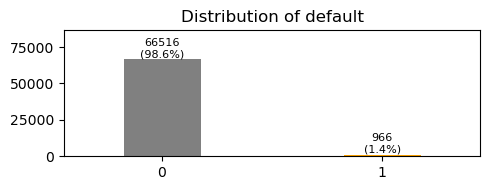

In [8]:
plot_binary_distribution(df_train, bar_width=0.35)

#### Correlation between the features
There seems to be no "near-perfect" correlation, but there is significant correlation between some pairs of variables. This could be an issue for some models such as Logistic regression

Text(0.5, 1.0, 'Correlation Matrix')

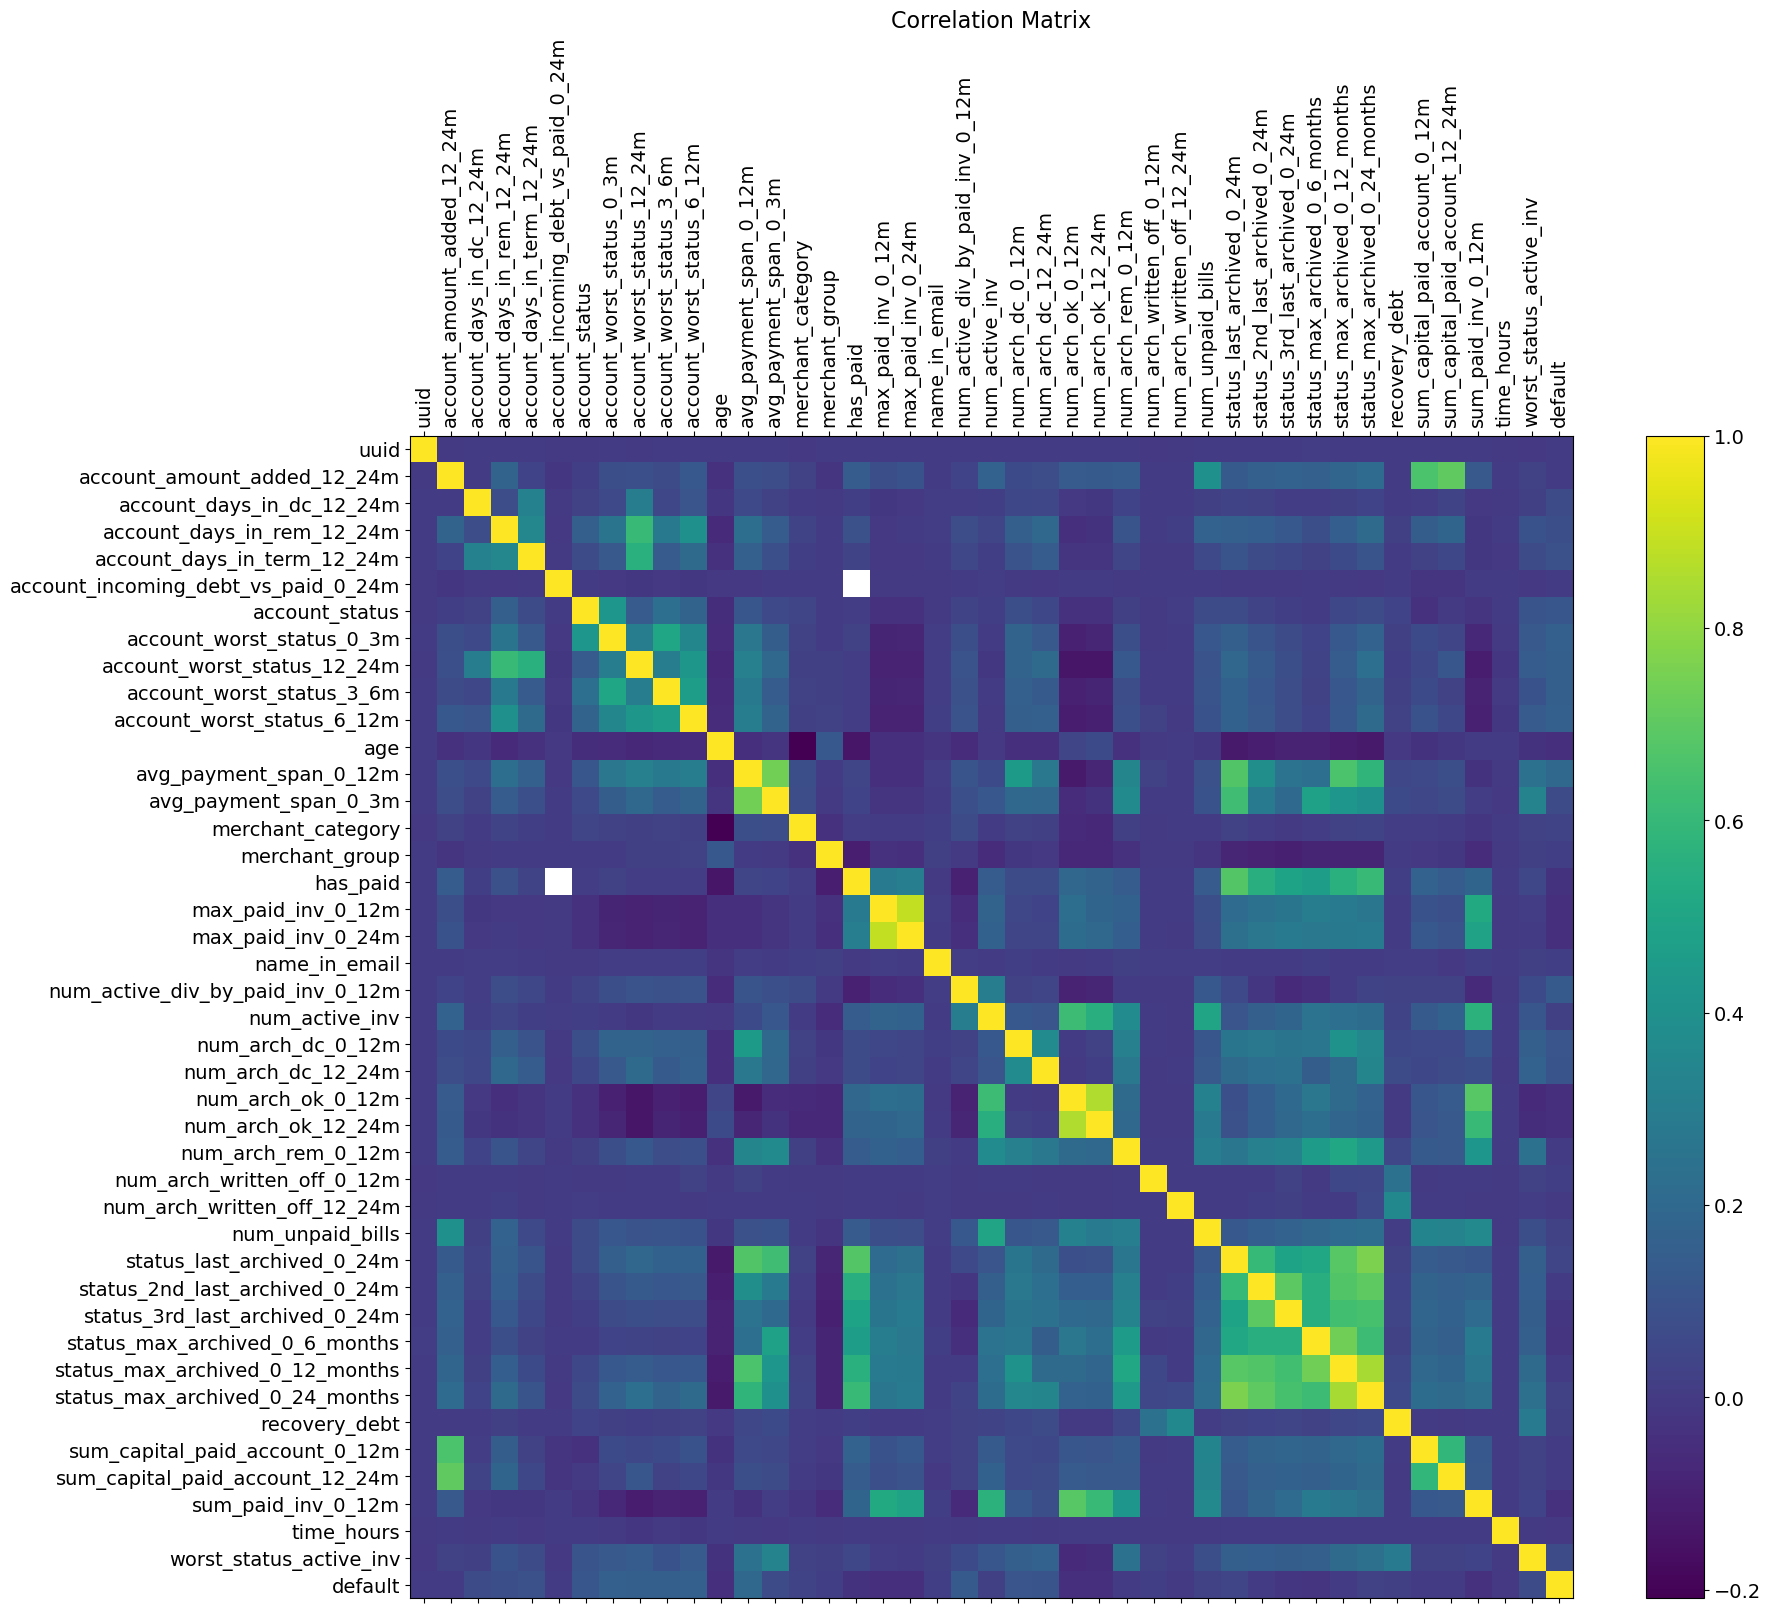

In [9]:
#Plotting the correlation matrix

df_train.dtypes
df_train['uuid']=df_train['uuid'].astype('category').cat.codes
df_train['merchant_category']=df_train['merchant_category'].astype('category').cat.codes
df_train['merchant_group']=df_train['merchant_group'].astype('category').cat.codes
df_train['name_in_email']=df_train['name_in_email'].astype('category').cat.codes

f = plt.figure(figsize=(19, 15))
plt.matshow(df_train.corr(), fignum=f.number)
plt.xticks(range(df_train.select_dtypes(['number']).shape[1]), df_train.select_dtypes(['number']).columns, fontsize=14, rotation=90)
plt.yticks(range(df_train.select_dtypes(['number']).shape[1]), df_train.select_dtypes(['number']).columns, fontsize=14)
cb = plt.colorbar()
cb.ax.tick_params(labelsize=14)
plt.title('Correlation Matrix', fontsize=16)

Feature 1: account_amount_added_12_24m

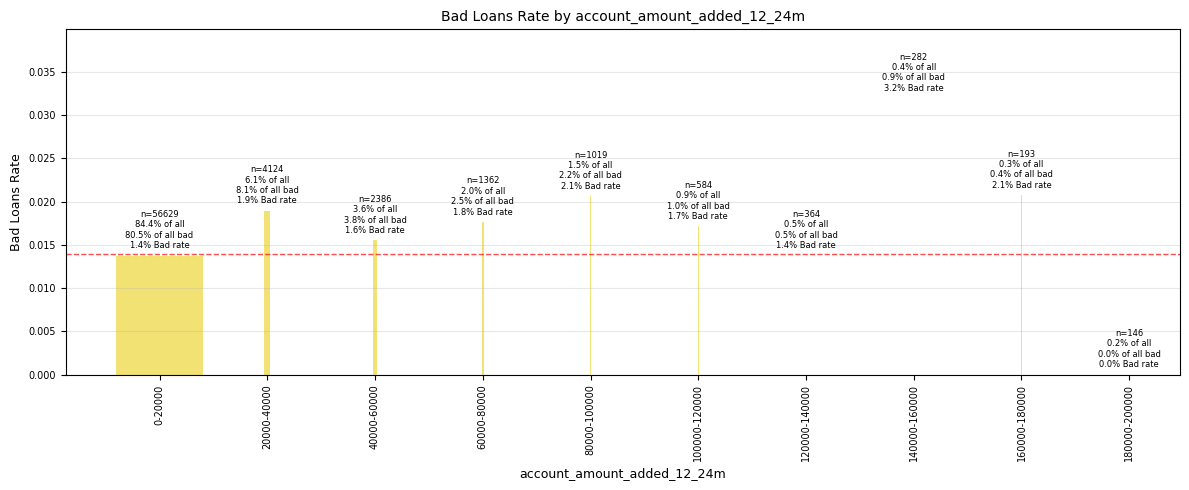

In [10]:
plot_bars_rel(df_train, 
feature='account_amount_added_12_24m',
 amount_limit=200000, 
 bucket_size=20000, 
 figsize=(12,5), 
 variable_bar_width=True, 
 hline=0.014, 
 short_x_labels=False, 
 max_categories=15)

Feature 2: account_days_in_dc_12_24m

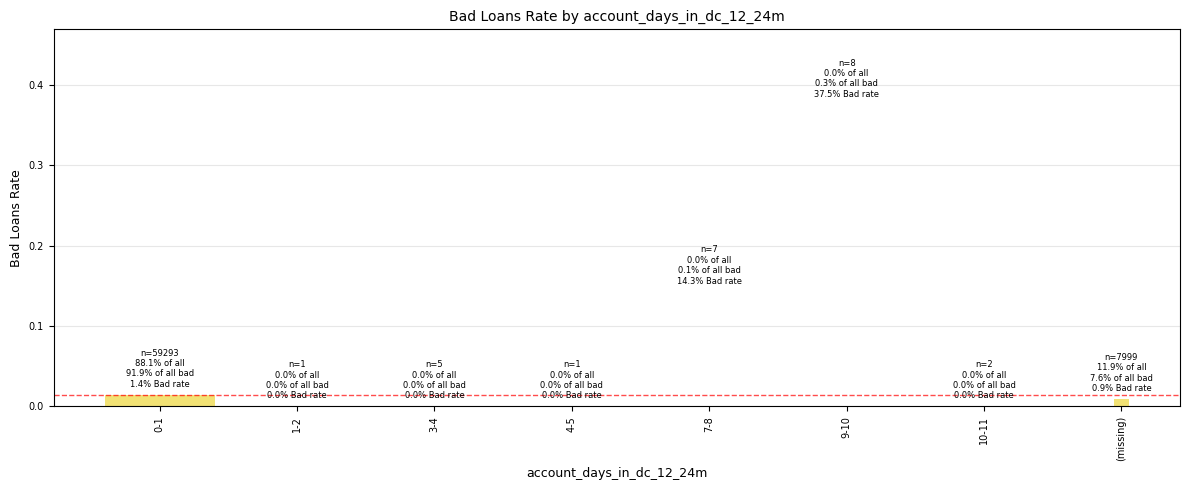

In [64]:
plot_bars_rel(df_train, 
feature='account_days_in_dc_12_24m',
 amount_limit=10, 
 bucket_size=1, 
 figsize=(12,5), 
 variable_bar_width=True, 
 hline=0.014, 
 short_x_labels=False, 
 max_categories=15)

Feature 3: account_days_in_rem_12_24m

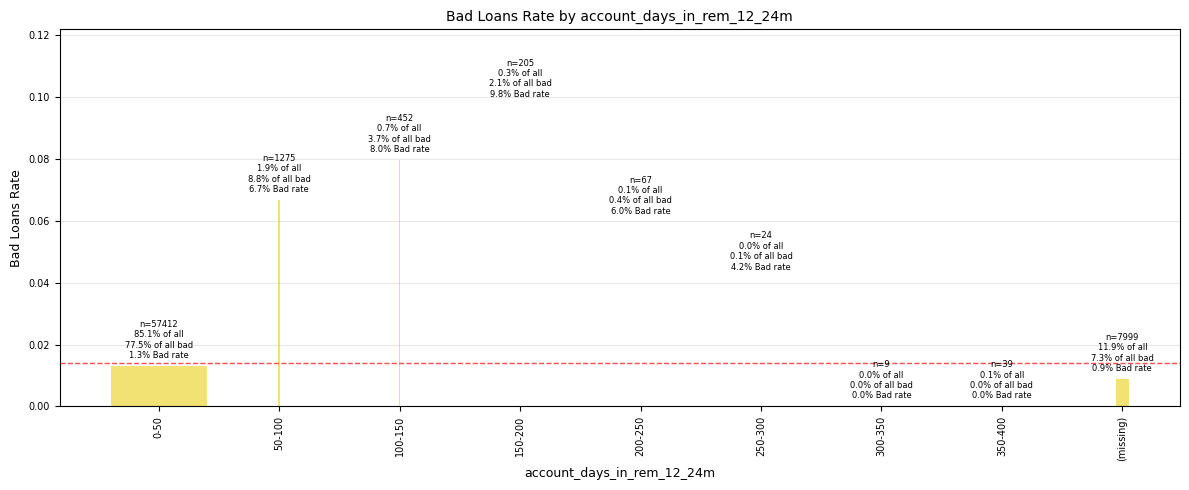

In [12]:
plot_bars_rel(df_train, 
feature='account_days_in_rem_12_24m',
 amount_limit=3000, 
 bucket_size=50, 
 figsize=(12,5), 
 variable_bar_width=True, 
 hline=0.014, 
 short_x_labels=False,
 )

Feature 4: account_days_in_term_12_24m

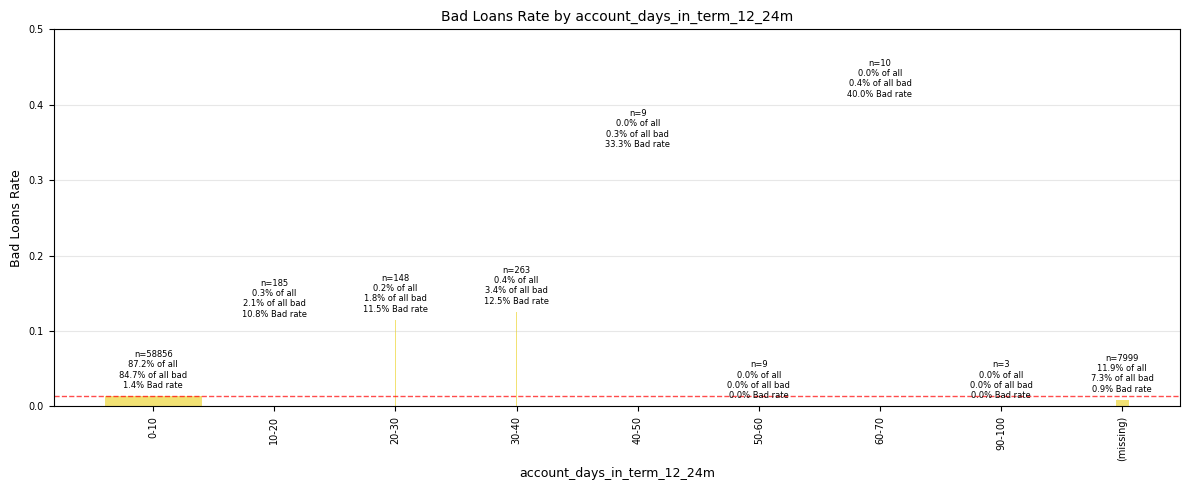

In [13]:
plot_bars_rel(df_train, 
feature='account_days_in_term_12_24m',
 amount_limit=500, 
 bucket_size=10, 
 figsize=(12,5), 
 variable_bar_width=True, 
 hline=0.014, 
 short_x_labels=False,
 )

Feature 5: account_incoming_debt_vs_paid_0_24m

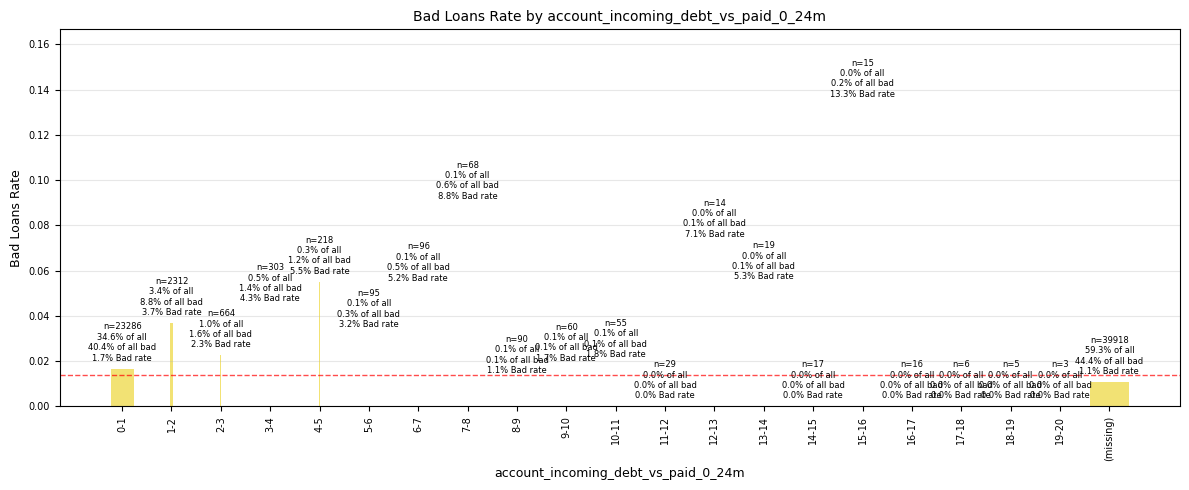

In [14]:
plot_bars_rel(df_train, 
feature='account_incoming_debt_vs_paid_0_24m',
 amount_limit=20, 
 bucket_size=1, 
 figsize=(12,5), 
 variable_bar_width=True, 
 hline=0.014, 
 short_x_labels=False,
 )

Feature 6: account_status

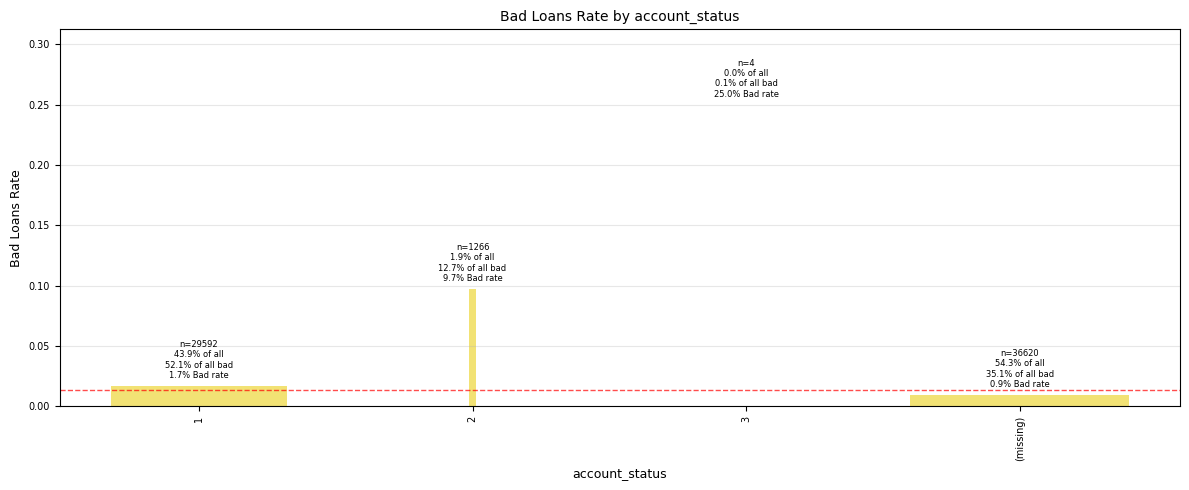

In [15]:
plot_bars_rel(df_train, 
feature='account_status',
 amount_limit=20, 
 bucket_size=1, 
 figsize=(12,5), 
 variable_bar_width=True, 
 hline=0.014, 
 short_x_labels=True,
 
 )

Feature 7: account_worst_status_0_3m

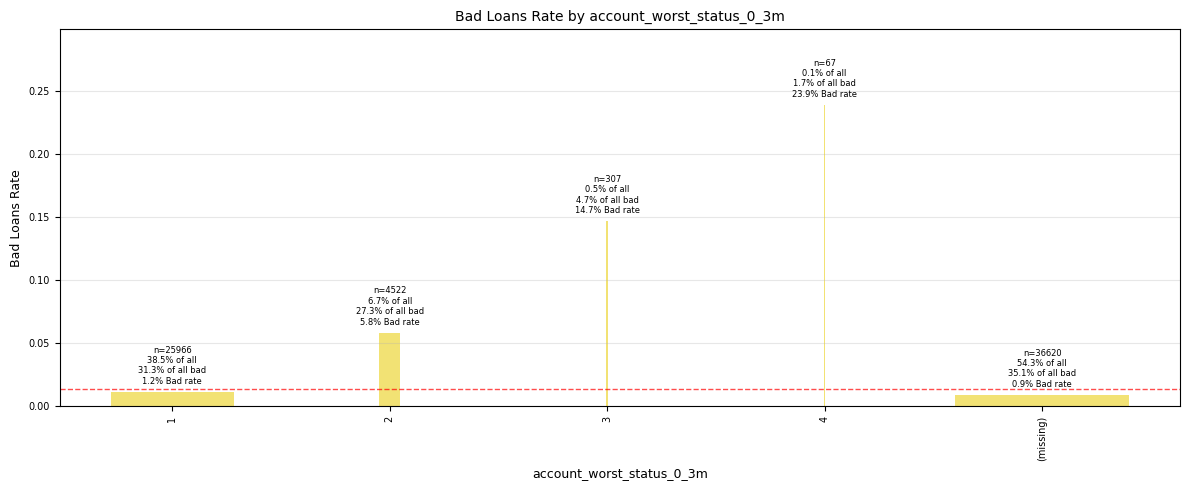

In [16]:
plot_bars_rel(df_train, 
feature='account_worst_status_0_3m',
 amount_limit=20, 
 bucket_size=1, 
 figsize=(12,5), 
 variable_bar_width=True, 
 hline=0.014, 
 short_x_labels=True,
 )

Feature 8: account_worst_status_3_6m

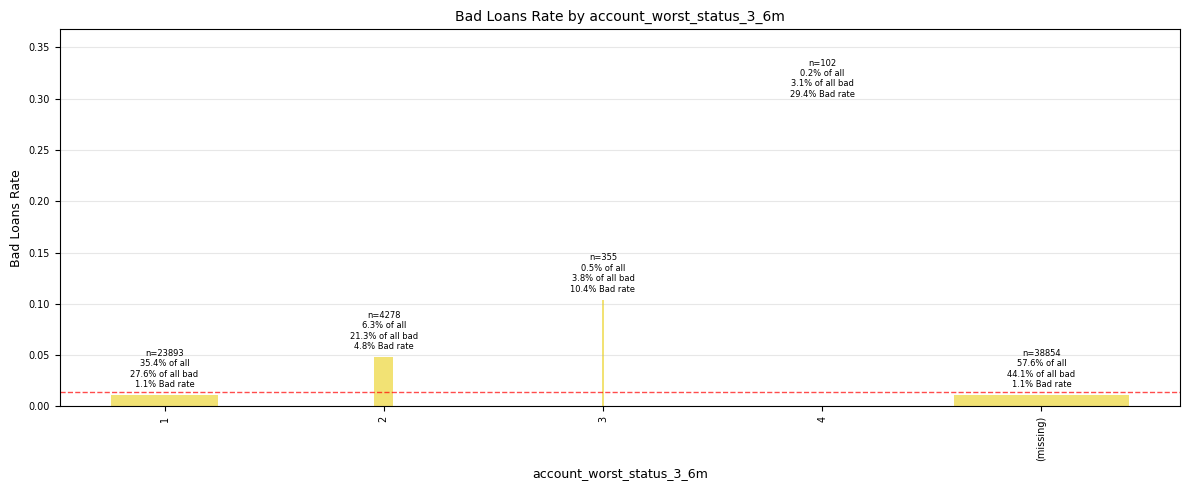

In [17]:
plot_bars_rel(df_train, 
feature='account_worst_status_3_6m',
 amount_limit=20, 
 bucket_size=1, 
 figsize=(12,5), 
 variable_bar_width=True, 
 hline=0.014, 
 short_x_labels=True,
 )

Feature 9: account_worst_status_6_12m

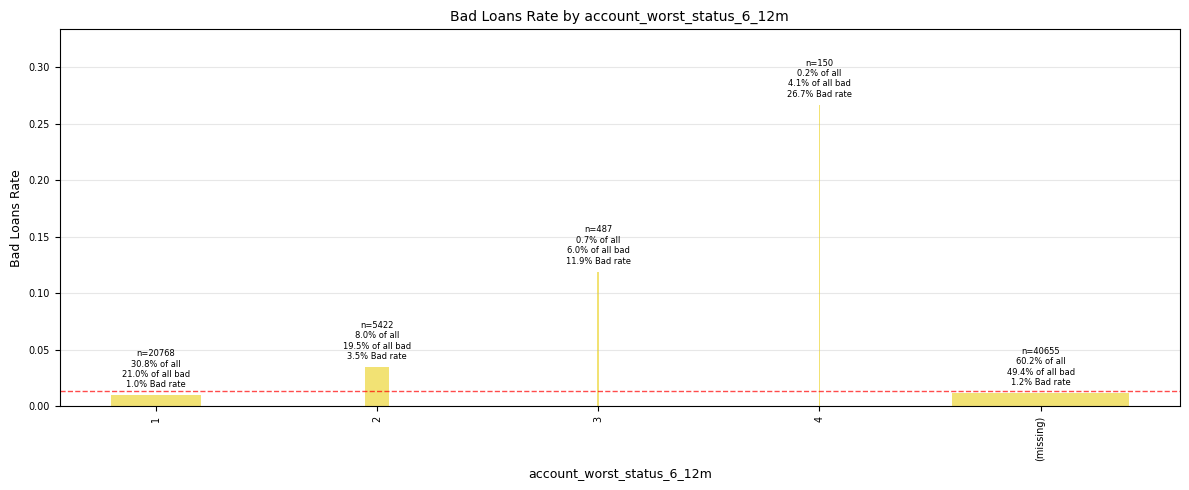

In [18]:
plot_bars_rel(df_train, 
feature='account_worst_status_6_12m',
 amount_limit=20, 
 bucket_size=1, 
 figsize=(12,5), 
 variable_bar_width=True, 
 hline=0.014, 
 short_x_labels=True,
 )

Feature 10: Age

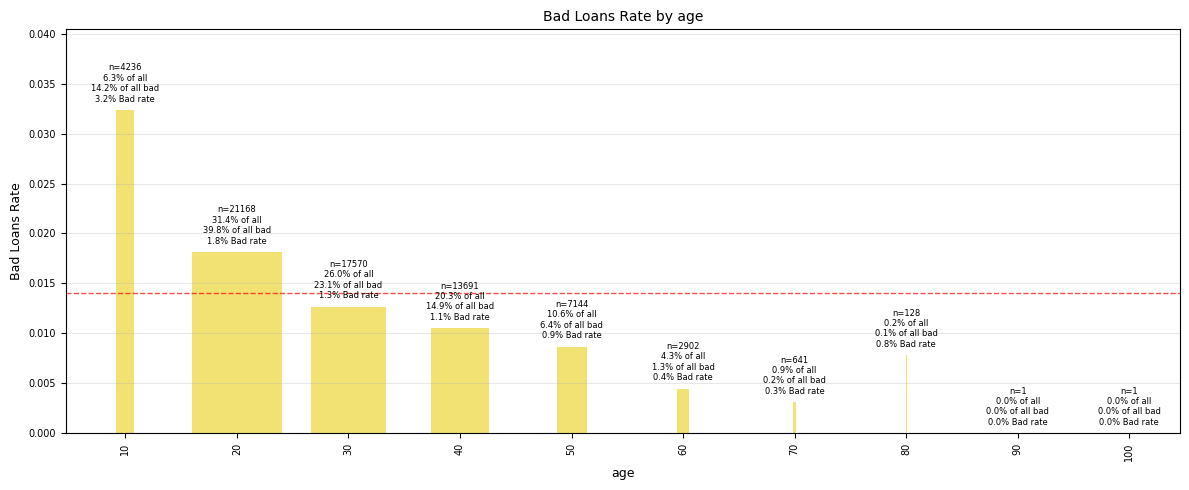

In [19]:
plot_bars_rel(df_train, 
feature='age',
 amount_limit=100, 
 bucket_size=10, 
 figsize=(12,5), 
 variable_bar_width=True, 
 hline=0.014, 
 short_x_labels=True,
 )

Feature 11: avg_payment_span_0_12m

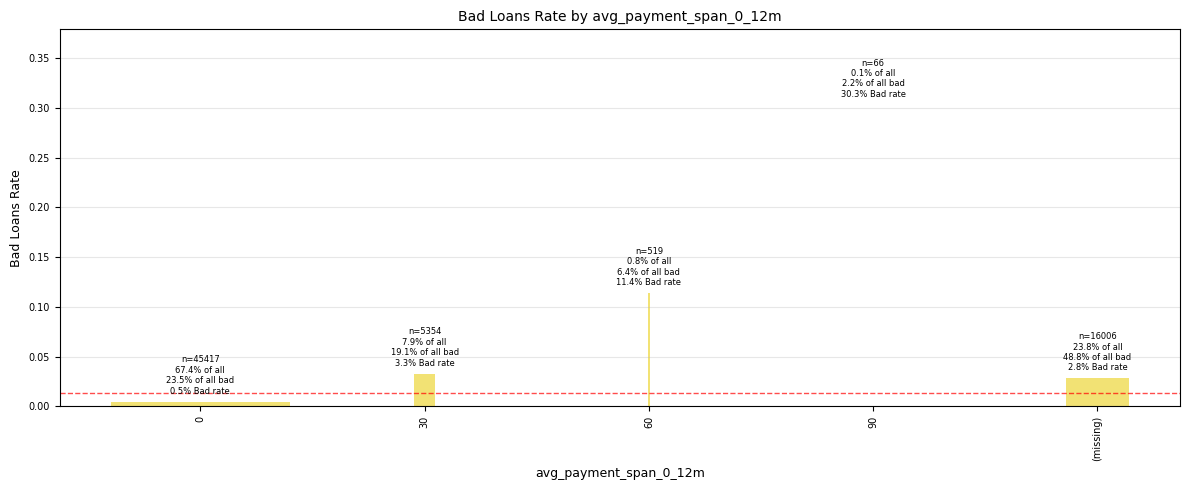

In [20]:
plot_bars_rel(df_train, 
feature='avg_payment_span_0_12m',
 amount_limit=100, 
 bucket_size=30, 
 figsize=(12,5), 
 variable_bar_width=True, 
 hline=0.014, 
 short_x_labels=True,
 )

Feature 12: avg_payment_span_0_3m

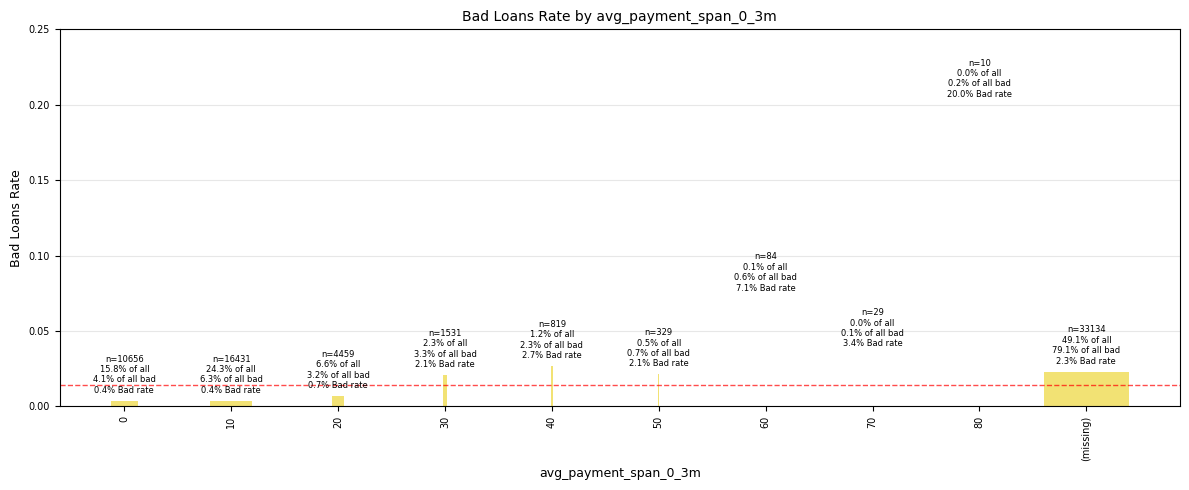

In [21]:
plot_bars_rel(df_train, 
feature='avg_payment_span_0_3m',
 amount_limit=90, 
 bucket_size=10, 
 figsize=(12,5), 
 variable_bar_width=True, 
 hline=0.014, 
 short_x_labels=True,
 )

Feature 13: merchant_category

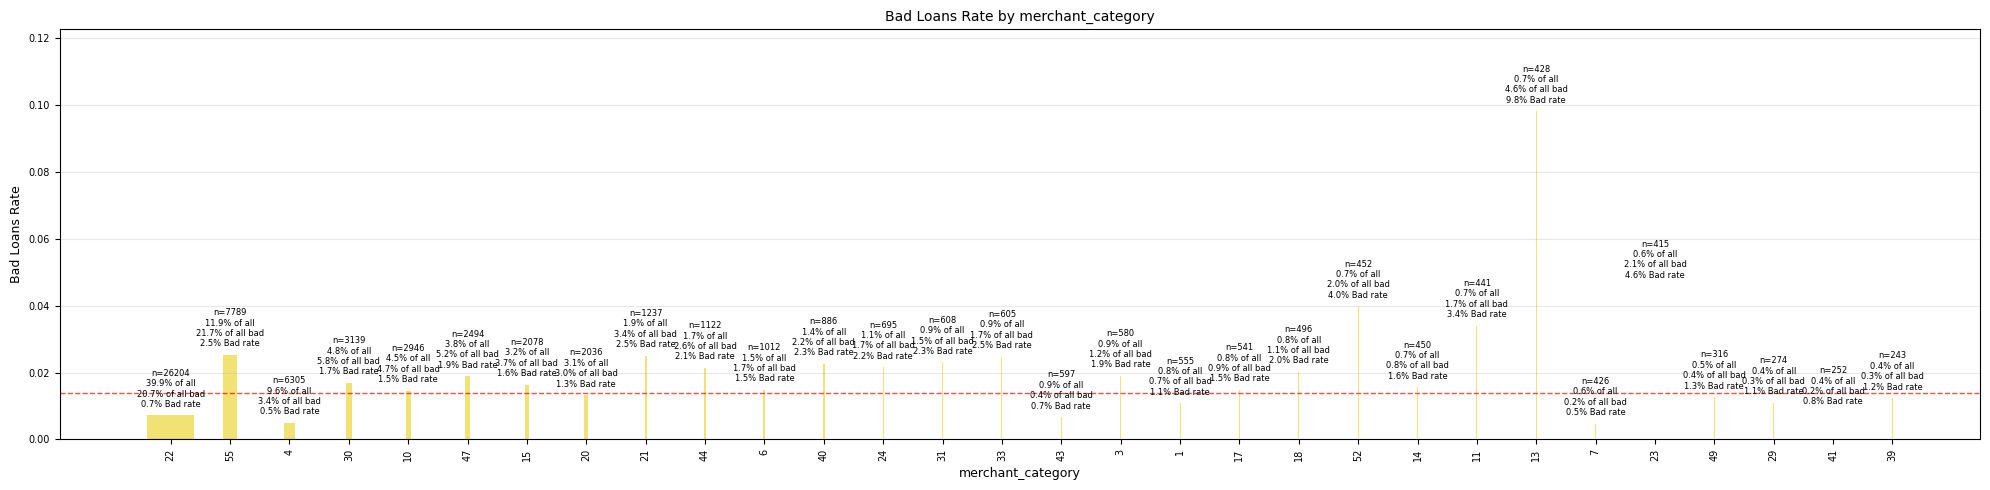

In [22]:
plot_bars_rel(df_train, 
feature='merchant_category',
 figsize=(20,5), 
 variable_bar_width=True, 
 hline=0.014, 
 short_x_labels=True,
 feature_type="categorical",
 max_categories=30
 )

Feature 14: merchant_group

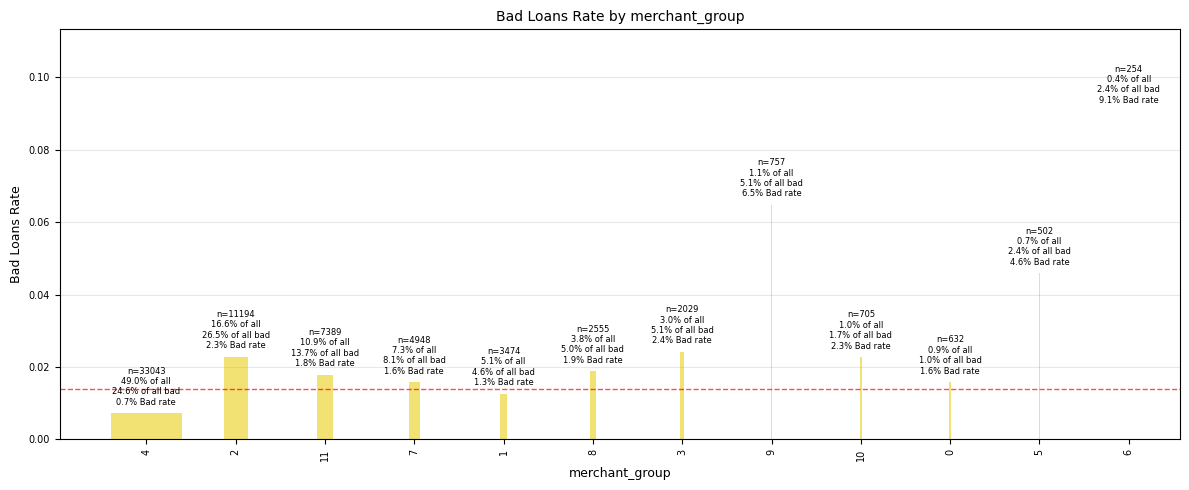

In [23]:
plot_bars_rel(df_train, 
feature='merchant_group',
 figsize=(12,5), 
 variable_bar_width=True, 
 hline=0.014, 
 short_x_labels=True,
 feature_type="categorical",
 max_categories=15
 )

Feature 15: has_paid

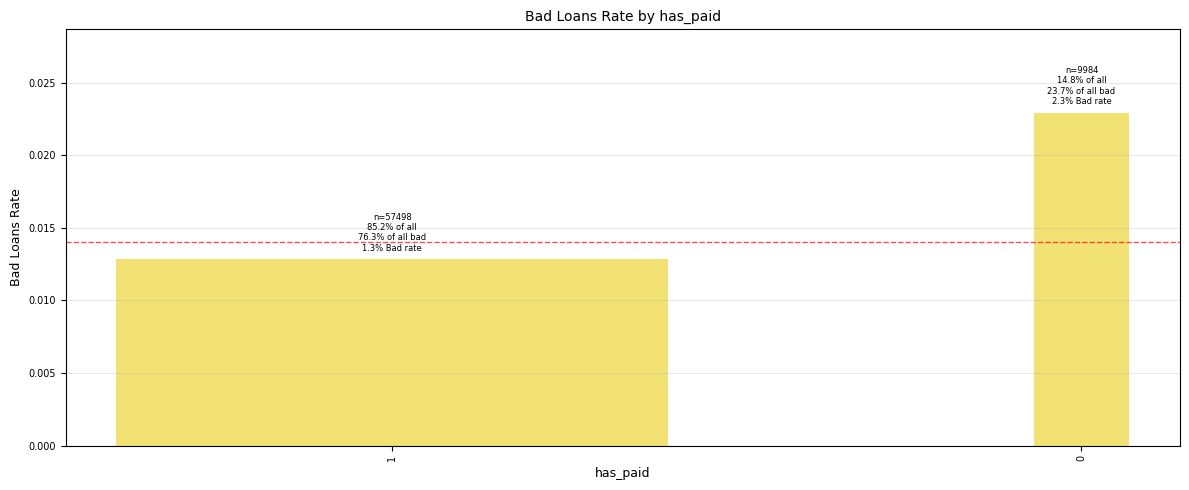

In [24]:
plot_bars_rel(df_train, 
feature='has_paid',
 figsize=(12,5), 
 variable_bar_width=True, 
 hline=0.014, 
 short_x_labels=True,
 feature_type="categorical",
 max_categories=15
 )

Feature 16: max_paid_inv_0_12m

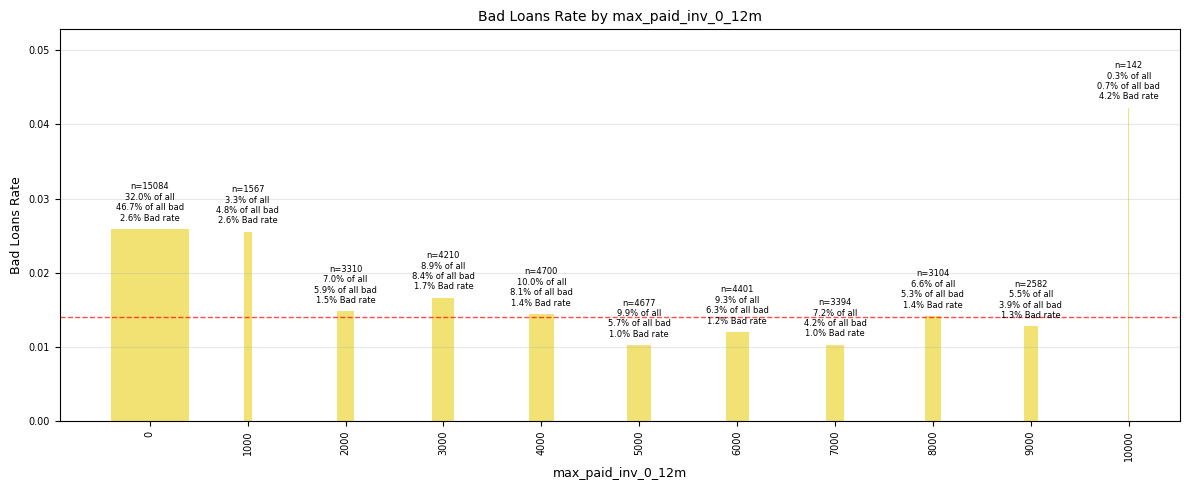

In [25]:
plot_bars_rel(df_train, 
feature='max_paid_inv_0_12m',
 amount_limit=10000, 
 bucket_size=1000, 
 figsize=(12,5), 
 variable_bar_width=True, 
 hline=0.014, 
 short_x_labels=True,
 max_categories=15
 )

Feature 17: max_paid_inv_0_24m

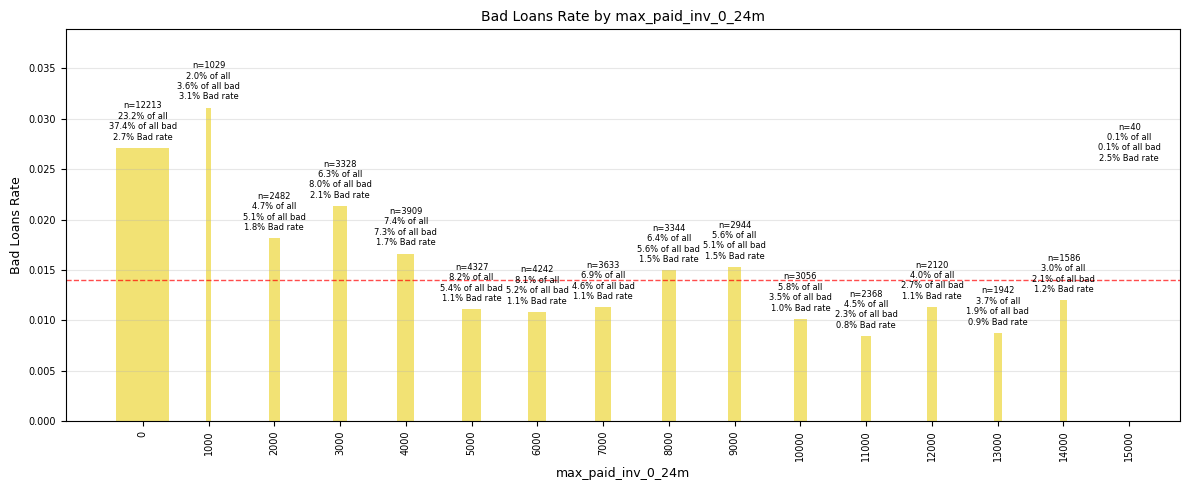

In [26]:
plot_bars_rel(df_train, 
feature='max_paid_inv_0_24m',
 amount_limit=15000, 
 bucket_size=1000, 
 figsize=(12,5), 
 variable_bar_width=True, 
 hline=0.014, 
 short_x_labels=True,
 max_categories=15
 )

Feature 18: name_in_email

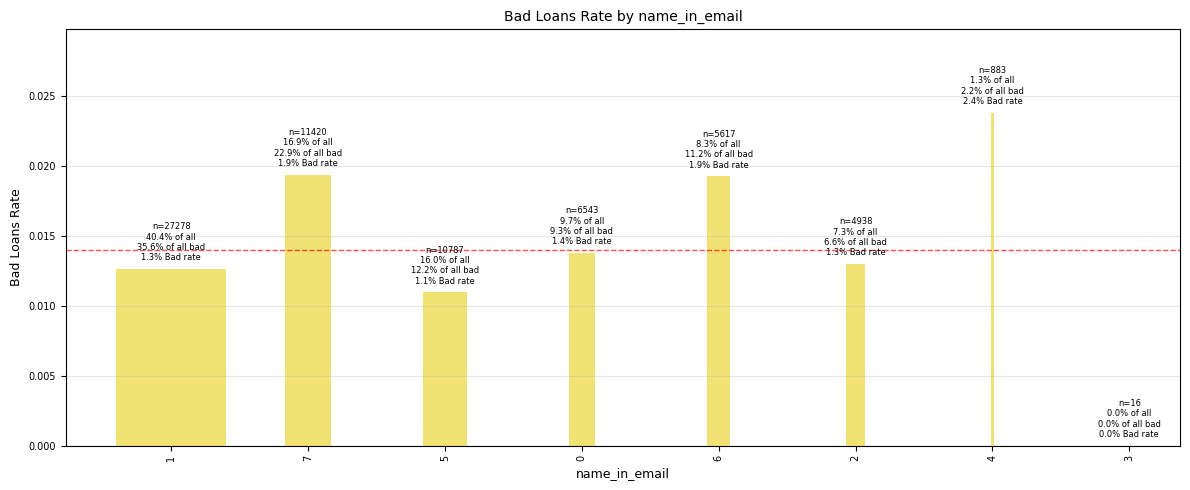

In [27]:
plot_bars_rel(df_train, 
feature='name_in_email',
 amount_limit=15000, 
 bucket_size=1000, 
 figsize=(12,5), 
 variable_bar_width=True, 
 hline=0.014, 
 short_x_labels=True,
 max_categories=15,
 feature_type="categorical"
 )

Feature 19: num_active_div_by_paid_inv_0_12m

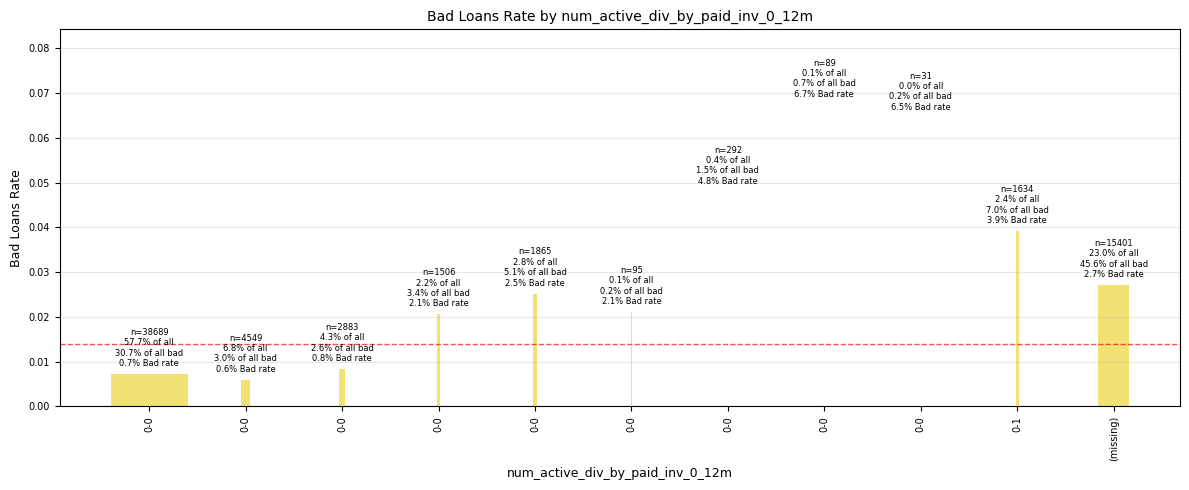

In [28]:
plot_bars_rel(df_train, 
feature='num_active_div_by_paid_inv_0_12m',
 amount_limit=1, 
 bucket_size=0.1, 
 figsize=(12,5), 
 variable_bar_width=True, 
 hline=0.014, 
 short_x_labels=False,
 max_categories=15,
 #feature_type="categorical"
 )

Feature 20: num_active_inv

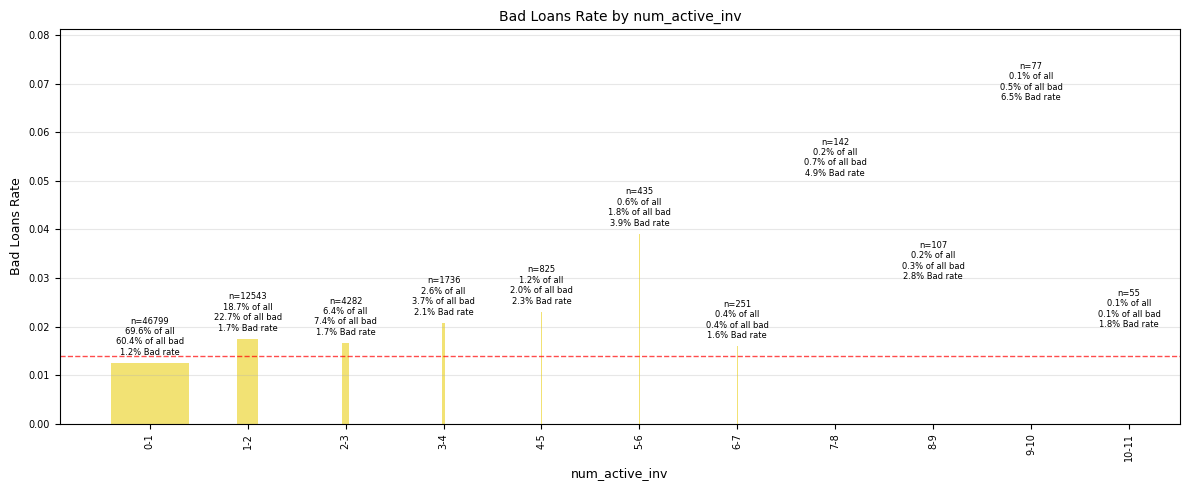

In [29]:
plot_bars_rel(df_train, 
feature='num_active_inv',
 amount_limit=10, 
 bucket_size=1, 
 figsize=(12,5), 
 variable_bar_width=True, 
 hline=0.014, 
 short_x_labels=False,
 max_categories=15,
 #feature_type="categorical"
 )

Feature 21: num_arch_dc_0_12m

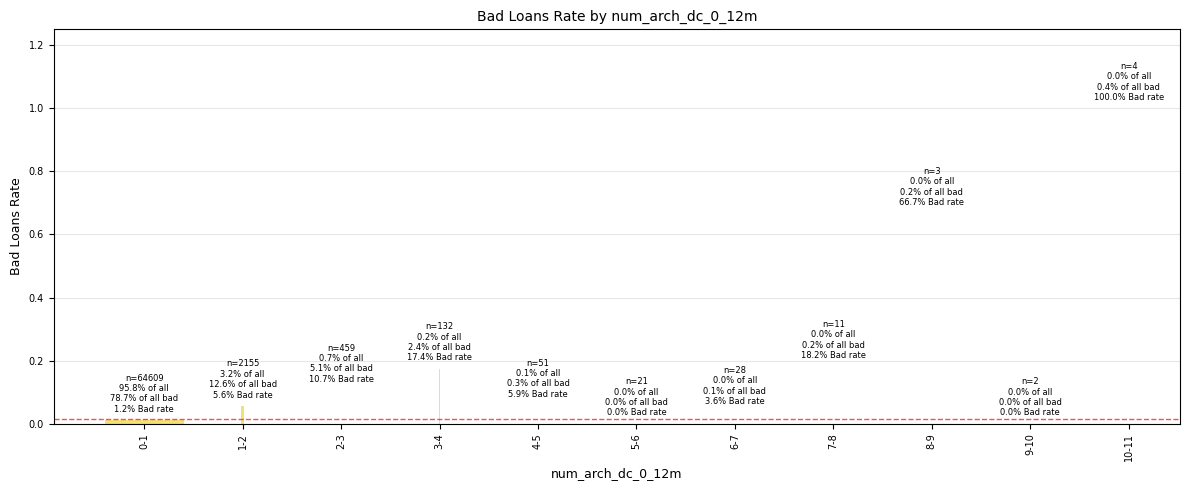

In [30]:
plot_bars_rel(df_train, 
feature='num_arch_dc_0_12m',
 amount_limit=10, 
 bucket_size=1, 
 figsize=(12,5), 
 variable_bar_width=True, 
 hline=0.014, 
 short_x_labels=False,
 max_categories=15,
 #feature_type="categorical"
 )

Feature 22: num_arch_dc_12_24m

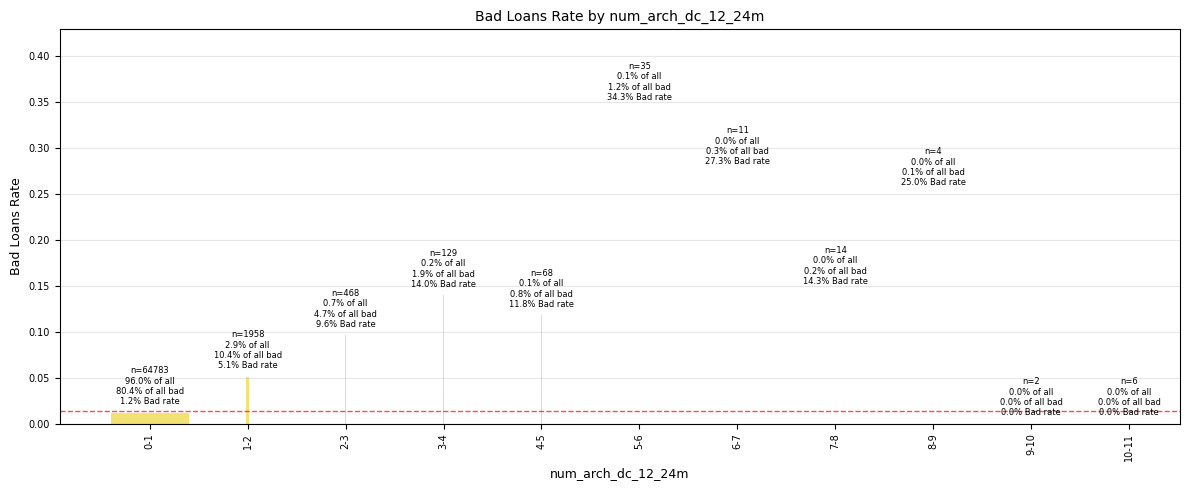

In [31]:
plot_bars_rel(df_train, 
feature='num_arch_dc_12_24m',
 amount_limit=10, 
 bucket_size=1, 
 figsize=(12,5), 
 variable_bar_width=True, 
 hline=0.014, 
 short_x_labels=False,
 max_categories=15,
 #feature_type="categorical"
 )

Feature 23: num_arch_ok_0_12m

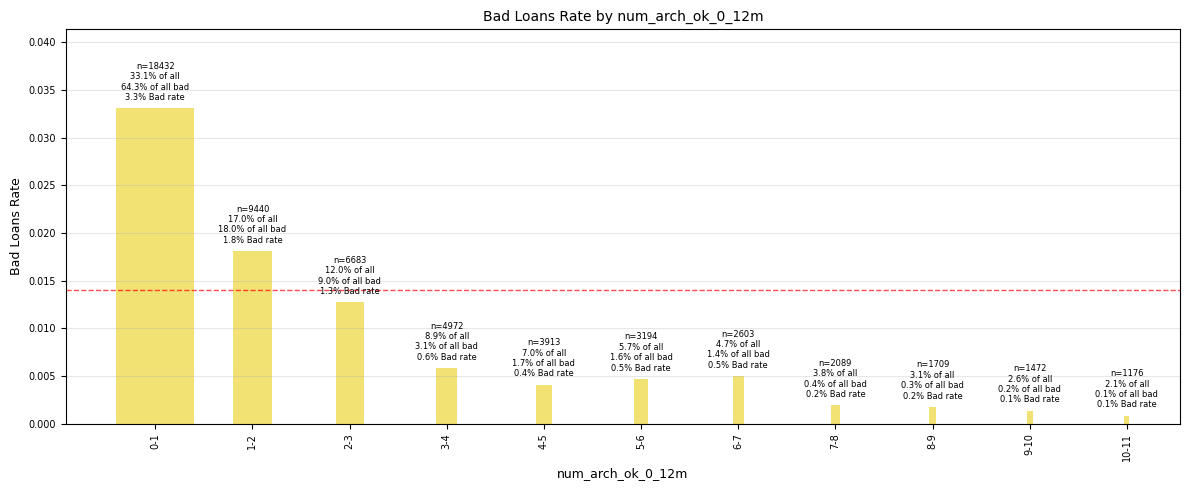

In [32]:
plot_bars_rel(df_train, 
feature='num_arch_ok_0_12m',
 amount_limit=10, 
 bucket_size=1, 
 figsize=(12,5), 
 variable_bar_width=True, 
 hline=0.014, 
 short_x_labels=False,
 max_categories=15,
 #feature_type="categorical"
 )

Feature 24: num_arch_ok_12_24m

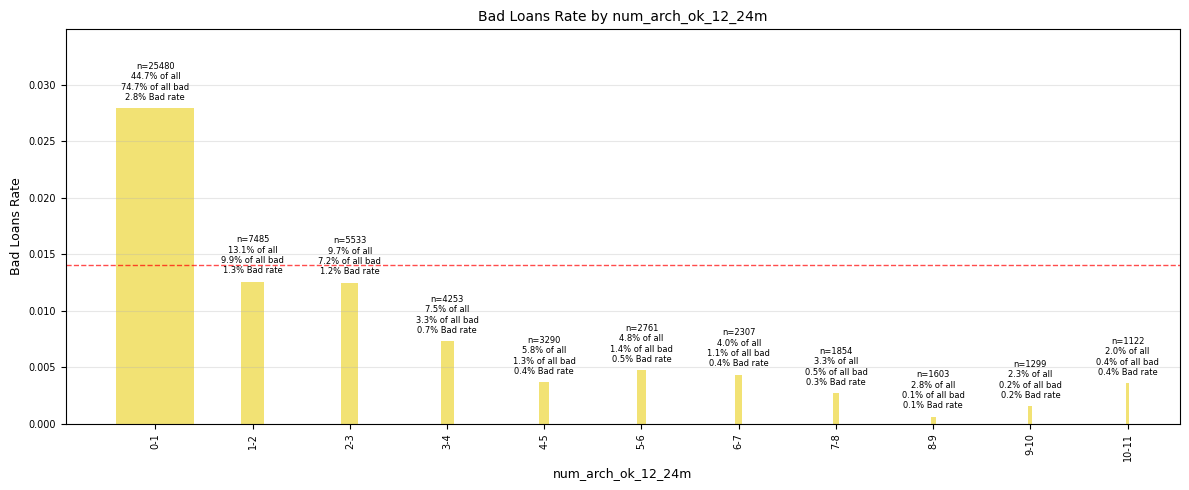

In [33]:
plot_bars_rel(df_train, 
feature='num_arch_ok_12_24m',
 amount_limit=10, 
 bucket_size=1, 
 figsize=(12,5), 
 variable_bar_width=True, 
 hline=0.014, 
 short_x_labels=False,
 max_categories=15,
 #feature_type="categorical"
 )

Feature 25: num_arch_rem_0_12m

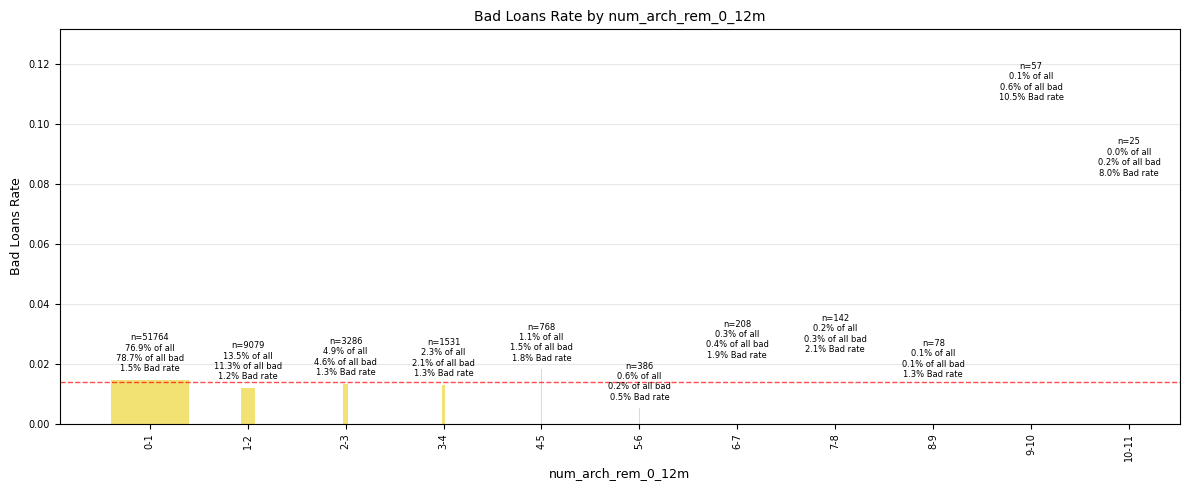

In [34]:
plot_bars_rel(df_train, 
feature='num_arch_rem_0_12m',
 amount_limit=10, 
 bucket_size=1, 
 figsize=(12,5), 
 variable_bar_width=True, 
 hline=0.014, 
 short_x_labels=False,
 max_categories=15,
 #feature_type="categorical"
 )

Feature 26: num_arch_written_off_0_12m

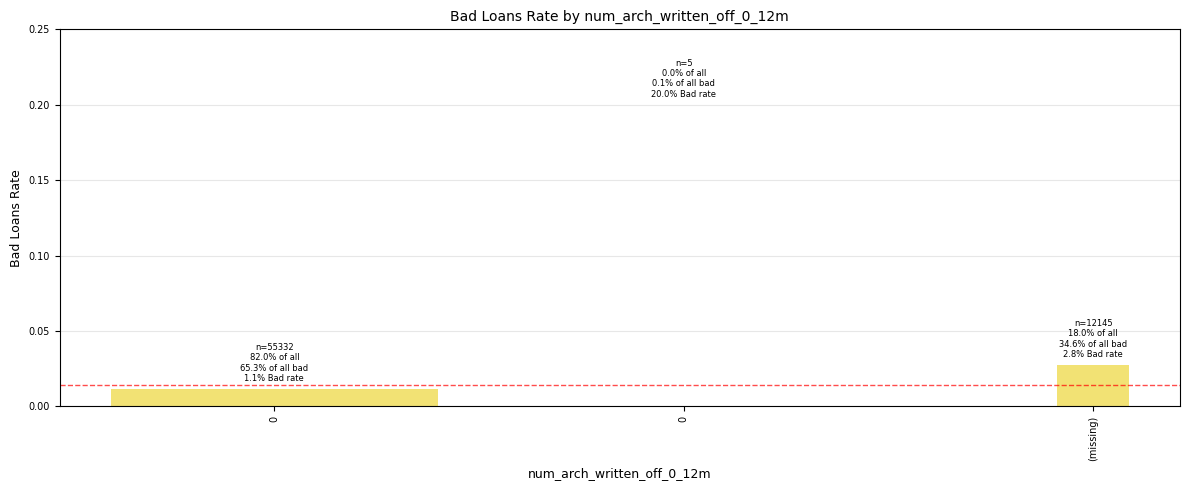

In [35]:
plot_bars_rel(df_train, 
feature='num_arch_written_off_0_12m',
 amount_limit=2, 
 bucket_size=0.1, 
 figsize=(12,5), 
 variable_bar_width=True, 
 hline=0.014, 
 short_x_labels=True,
 max_categories=15,
 #feature_type="categorical"
 )

Feature 27: num_arch_written_off_12_24m

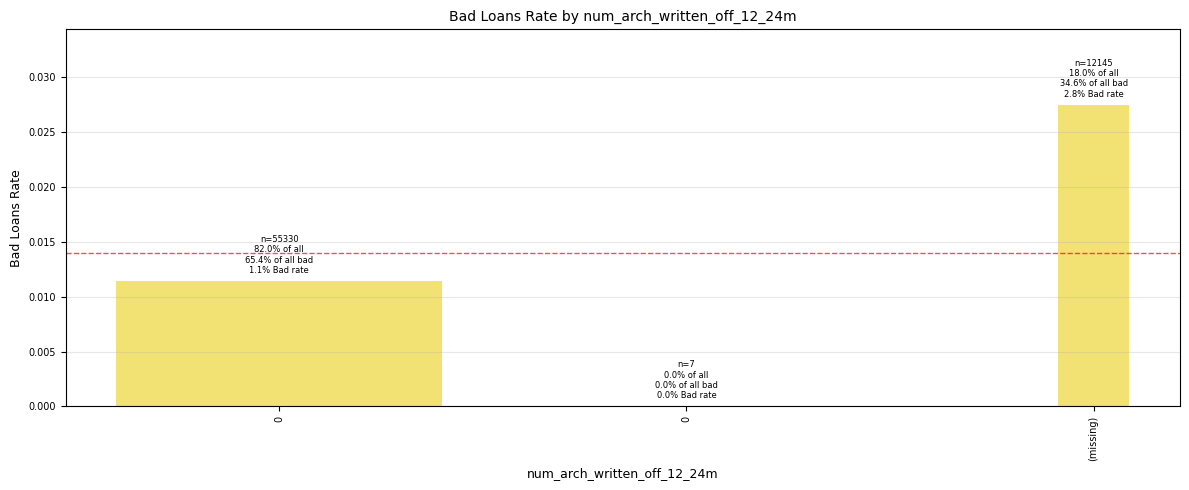

In [36]:
plot_bars_rel(df_train, 
feature='num_arch_written_off_12_24m',
 amount_limit=2, 
 bucket_size=0.1, 
 figsize=(12,5), 
 variable_bar_width=True, 
 hline=0.014, 
 short_x_labels=True,
 max_categories=15,
 #feature_type="categorical"
 )

Feature 28: num_unpaid_bills

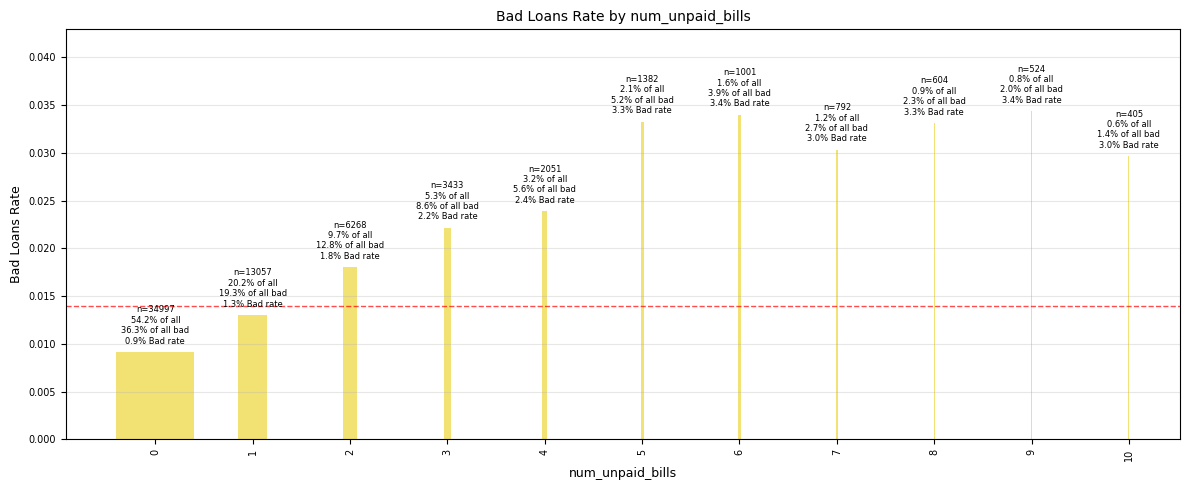

In [37]:
plot_bars_rel(df_train, 
feature='num_unpaid_bills',
 amount_limit=10, 
 bucket_size=1, 
 figsize=(12,5), 
 variable_bar_width=True, 
 hline=0.014, 
 short_x_labels=True,
 max_categories=15,
 #feature_type="categorical"
 )

Feature 29: status_last_archived_0_24m

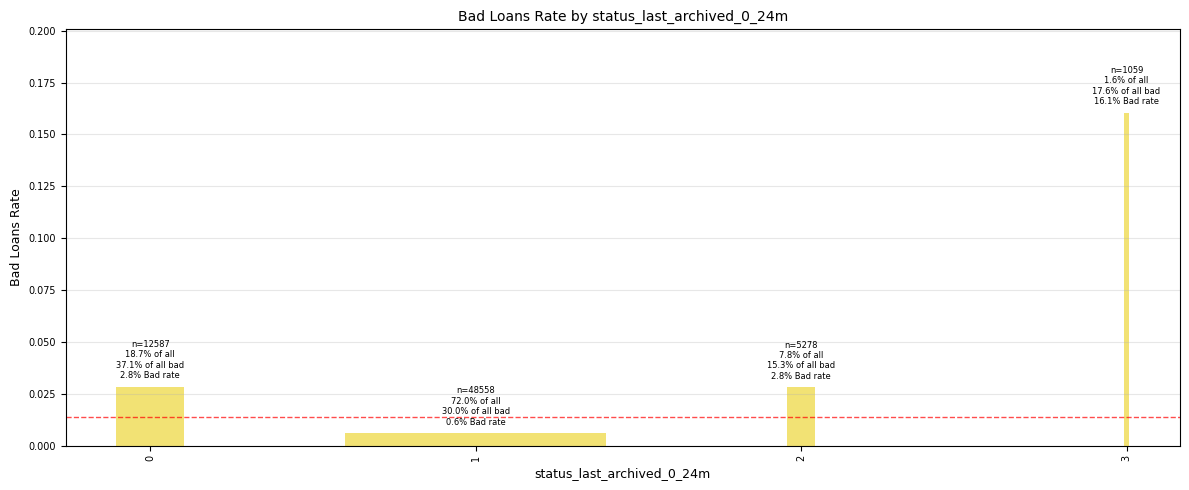

In [38]:
plot_bars_rel(df_train, 
feature='status_last_archived_0_24m',
 amount_limit=10, 
 bucket_size=1, 
 figsize=(12,5), 
 variable_bar_width=True, 
 hline=0.014, 
 short_x_labels=True,
 max_categories=15,
 #feature_type="categorical"
 )

Feature 30: status_2nd_last_archived_0_24m

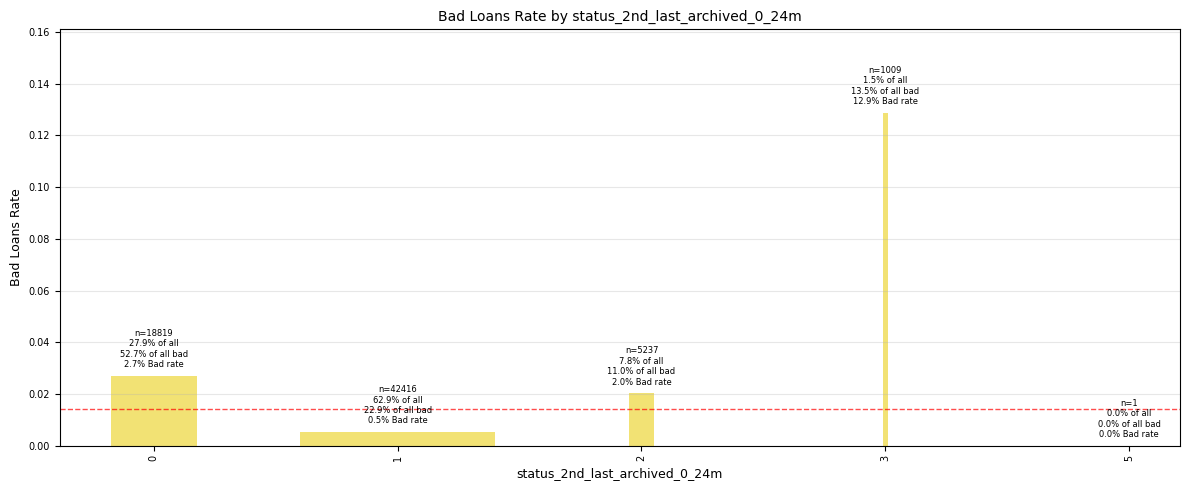

In [39]:
plot_bars_rel(df_train, 
feature='status_2nd_last_archived_0_24m',
 amount_limit=10, 
 bucket_size=1, 
 figsize=(12,5), 
 variable_bar_width=True, 
 hline=0.014, 
 short_x_labels=True,
 max_categories=15,
 #feature_type="categorical"
 )

Feature 31: status_3rd_last_archived_0_24m

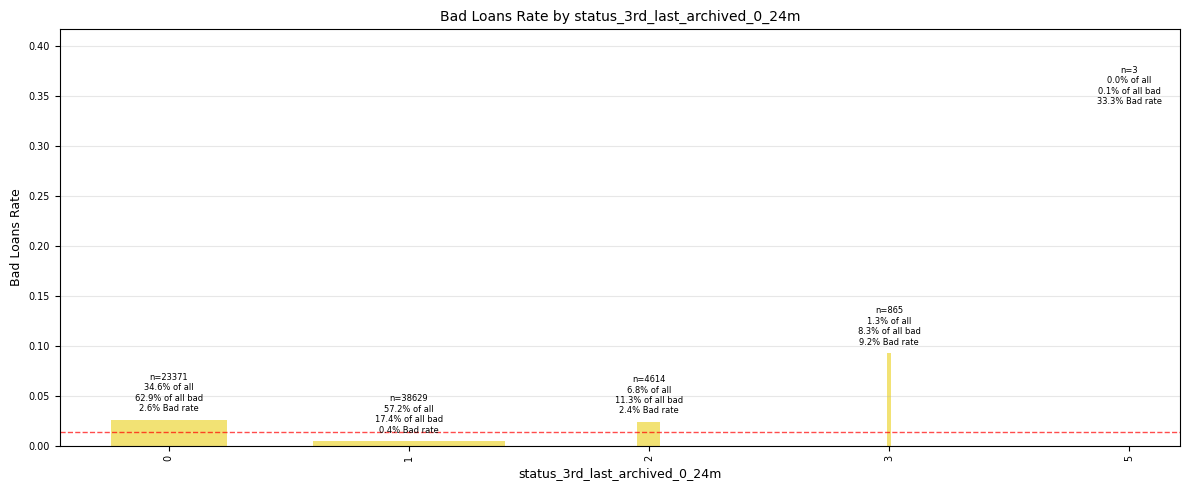

In [40]:
plot_bars_rel(df_train, 
feature='status_3rd_last_archived_0_24m',
 amount_limit=10, 
 bucket_size=1, 
 figsize=(12,5), 
 variable_bar_width=True, 
 hline=0.014, 
 short_x_labels=True,
 max_categories=15,
 #feature_type="categorical"
 )

Feature 32: status_max_archived_0_6_months

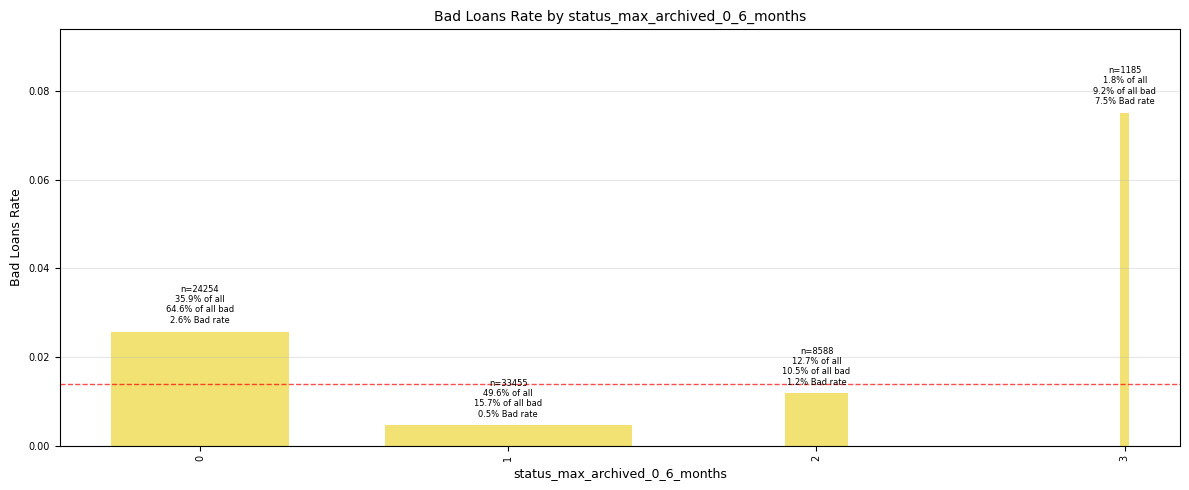

In [41]:
plot_bars_rel(df_train, 
feature='status_max_archived_0_6_months',
 amount_limit=10, 
 bucket_size=1, 
 figsize=(12,5), 
 variable_bar_width=True, 
 hline=0.014, 
 short_x_labels=True,
 max_categories=15,
 #feature_type="categorical"
 )

Feature 33: status_max_archived_0_12_months

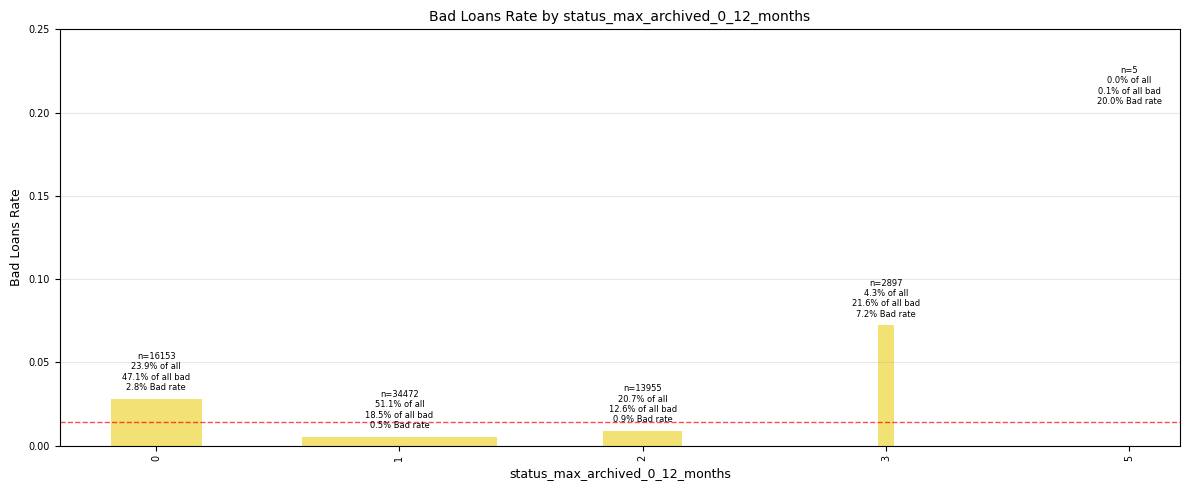

In [42]:
plot_bars_rel(df_train, 
feature='status_max_archived_0_12_months',
 amount_limit=10, 
 bucket_size=1, 
 figsize=(12,5), 
 variable_bar_width=True, 
 hline=0.014, 
 short_x_labels=True,
 max_categories=15,
 #feature_type="categorical"
 )

Feature 34: status_max_archived_0_24_months

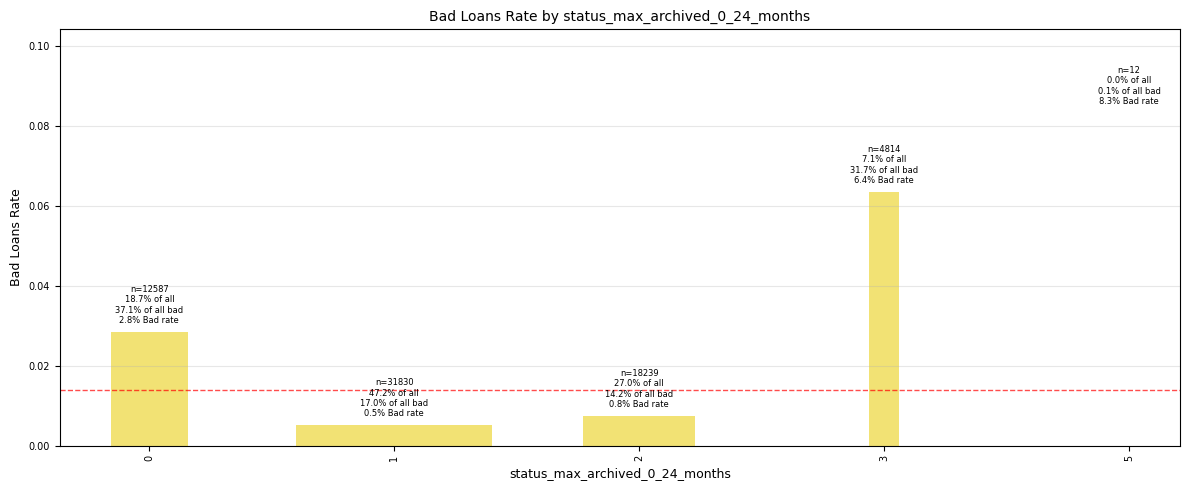

In [43]:
plot_bars_rel(df_train, 
feature='status_max_archived_0_24_months',
 amount_limit=10, 
 bucket_size=1, 
 figsize=(12,5), 
 variable_bar_width=True, 
 hline=0.014, 
 short_x_labels=True,
 max_categories=15,
 #feature_type="categorical"
 )

Feature 35: recovery_debt

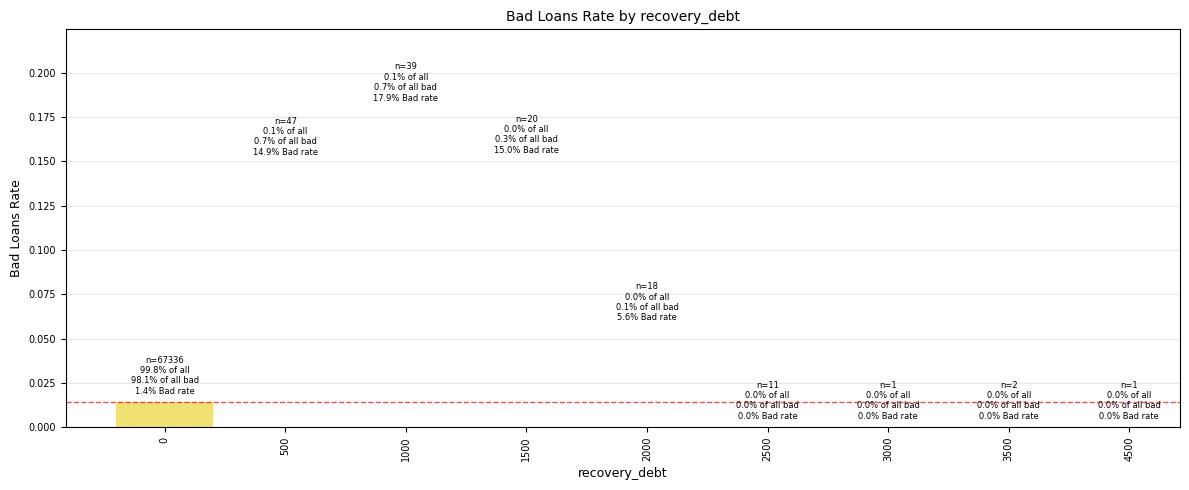

In [44]:
plot_bars_rel(df_train, 
feature='recovery_debt',
 amount_limit=5000, 
 bucket_size=500, 
 figsize=(12,5), 
 variable_bar_width=True, 
 hline=0.014, 
 short_x_labels=True,
 max_categories=15,
 #feature_type="categorical"
 )

Feature 36: sum_capital_paid_account_0_12m

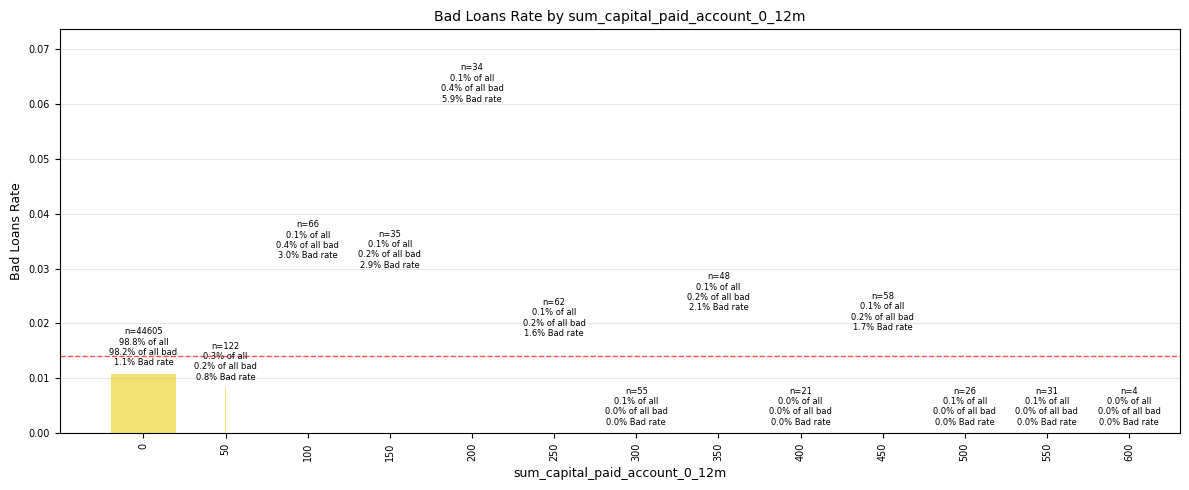

In [45]:
plot_bars_rel(df_train, 
feature='sum_capital_paid_account_0_12m',
 amount_limit=600, 
 bucket_size=50, 
 figsize=(12,5), 
 variable_bar_width=True, 
 hline=0.014, 
 short_x_labels=True,
 max_categories=15,
 #feature_type="categorical"
 )

Feature 37: sum_capital_paid_account_12_24m

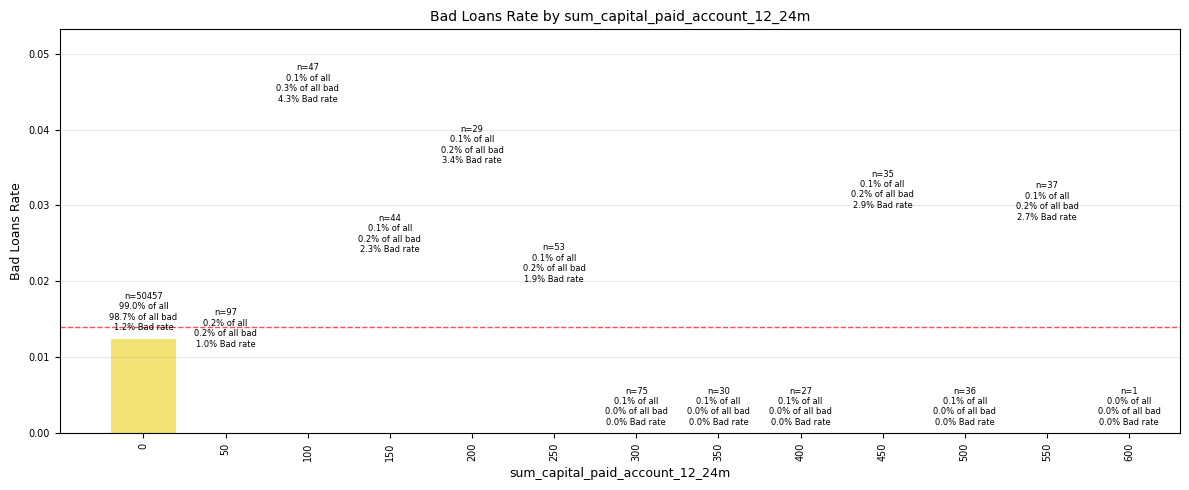

In [46]:
plot_bars_rel(df_train, 
feature='sum_capital_paid_account_12_24m',
 amount_limit=600, 
 bucket_size=50, 
 figsize=(12,5), 
 variable_bar_width=True, 
 hline=0.014, 
 short_x_labels=True,
 max_categories=15,
 #feature_type="categorical"
 )

Feature 38: sum_paid_inv_0_12m

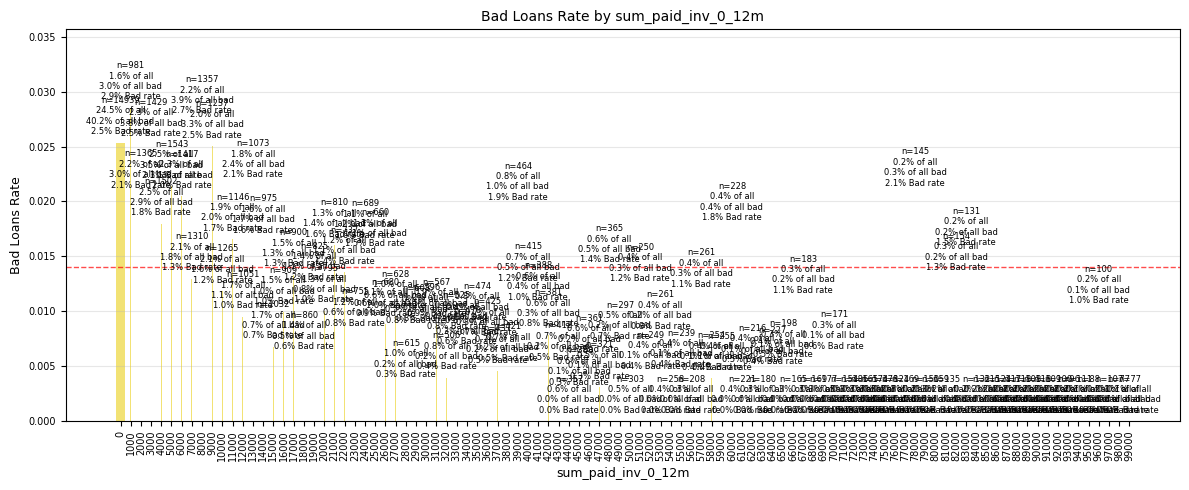

In [47]:
plot_bars_rel(df_train, 
feature='sum_paid_inv_0_12m',
 amount_limit=100000, 
 bucket_size=1000, 
 figsize=(12,5), 
 variable_bar_width=True, 
 hline=0.014, 
 short_x_labels=True,
 max_categories=15,
 #feature_type="categorical"
 )

Feature 39: time_hours

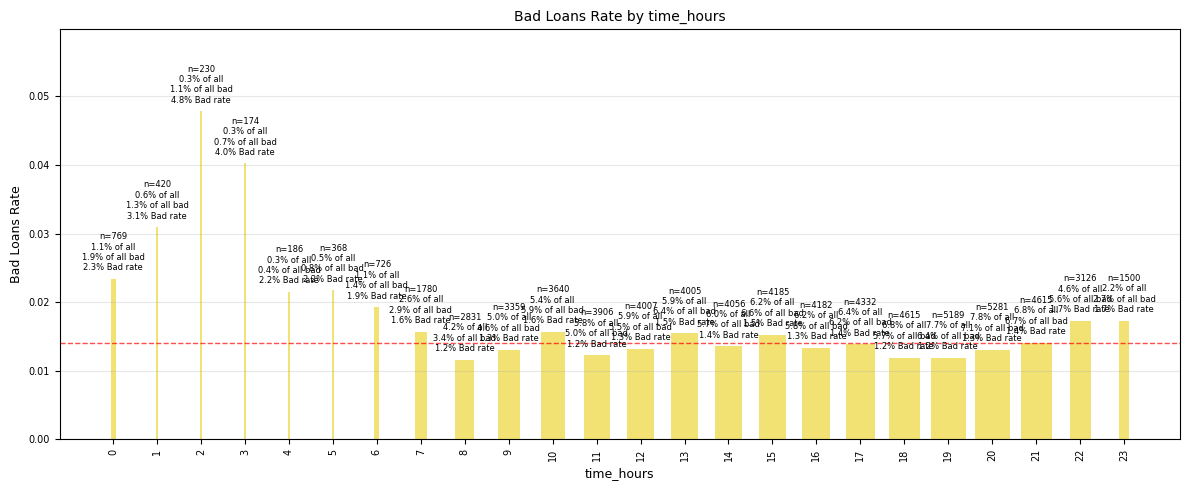

In [48]:
plot_bars_rel(df_train, 
feature='time_hours',
 amount_limit=24, 
 bucket_size=1, 
 figsize=(12,5), 
 variable_bar_width=True, 
 hline=0.014, 
 short_x_labels=True,
 max_categories=24,
 #feature_type="categorical"
 )

Feature 40: worst_status_active_inv

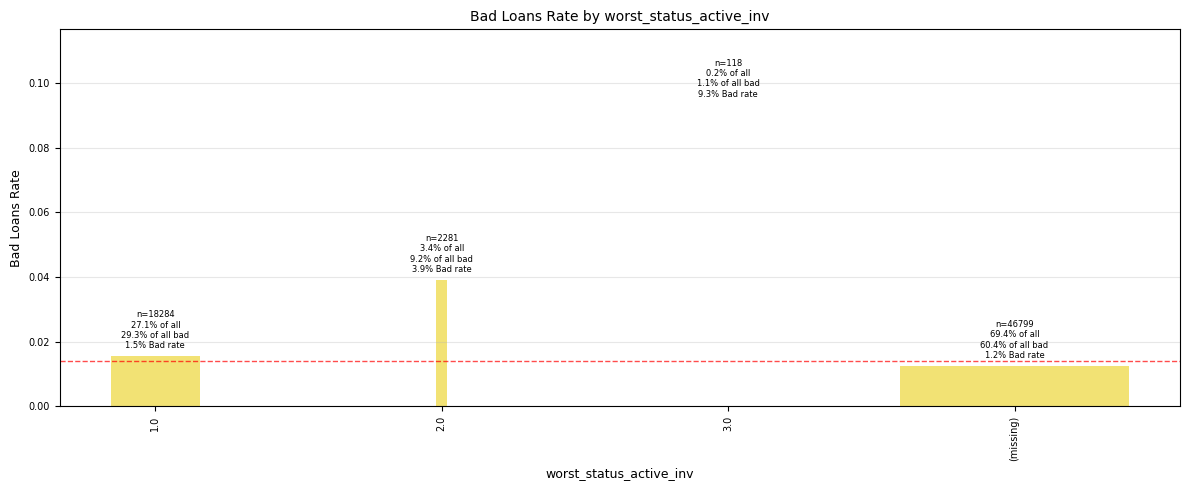

In [49]:
plot_bars_rel(df_train, 
feature='worst_status_active_inv',
 amount_limit=24, 
 bucket_size=1, 
 figsize=(12,5), 
 variable_bar_width=True, 
 hline=0.014, 
 short_x_labels=True,
 max_categories=24,
 feature_type="categorical"
 )

Feature 41: account_worst_status_12_24m

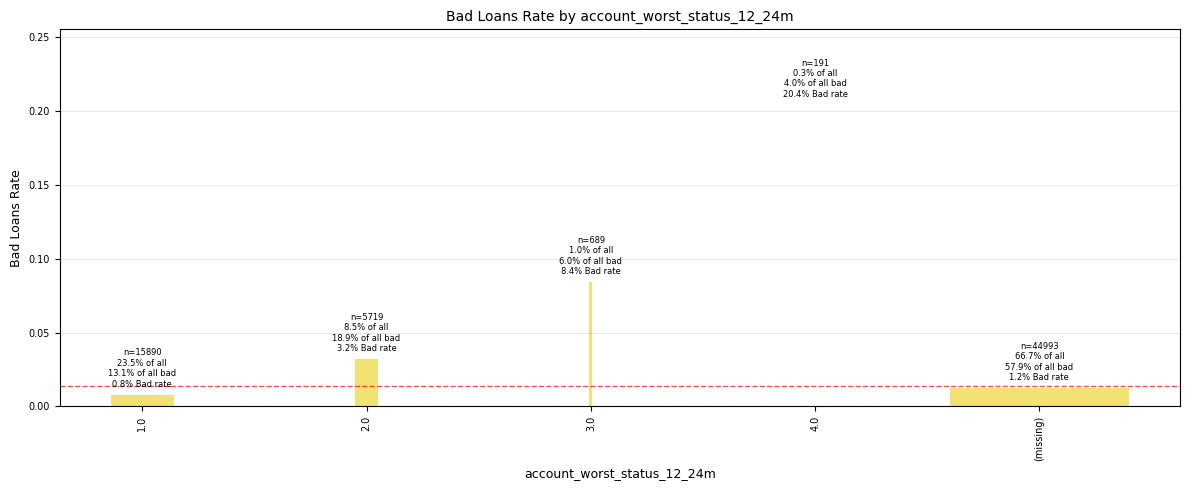

In [53]:

plot_bars_rel(df_train, 
feature='account_worst_status_12_24m',
 amount_limit=24, 
 bucket_size=1, 
 figsize=(12,5), 
 variable_bar_width=True, 
 hline=0.014, 
 short_x_labels=True,
 max_categories=24,
 feature_type="categorical"
 )